# Backbone Run Names

## Merge backbone dictionaries and create classifier summary dictionary

In [6]:
import csv
import os
from typing import Dict, Any, List, Union, Optional

# --- Config ---
BACKBONE_FILES = [
    "backbones_inf.csv",
    "backbones_l1.csv",
    "backbones_l2.csv",
]
CLASSIFIERS_CSV = "all_classifier_runs.csv"

ALLOWED_FIELDS = {"ID", "contrastive_loss_weight", "loss_norm_type"}
ACCURACY_FIELDS = [
    "validation/accuracy/dataloader_idx_0",
    "validation/ood/accuracy/dataloader_idx_1",
]

# Candidate columns for the backbone/classifier "run name"
BACKBONE_NAME_CANDIDATES = ["backbone", "name", "model", "architecture", "arch", "run_name", "backbone_run_name"]
CLASSIFIER_NAME_CANDIDATES = ["classifier", "classifier_name", "classifier_run_name", "name", "run_name", "experiment", "exp_name", "model"]

# ---------- Function from earlier (trimmed to allowed fields) ----------
def _coerce(value: Optional[str]):
    if value is None:
        return None
    s = str(value).strip()
    if s == "":
        return None
    low = s.lower()
    if low in ("true", "false"):
        return low == "true"
    try:
        return int(s)
    except ValueError:
        pass
    try:
        return float(s)  # also handles 'inf', '-inf', 'nan'
    except ValueError:
        pass
    return s

def load_backbones_dict(
    csv_path: str,
    name_candidates: List[str] = None
) -> Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]]:
    """
    Build {backbone_run_name: {ID, contrastive_loss_weight, loss_norm_type}}.
    If a run name appears multiple times, the value becomes a list of such dicts.
    Auto-detects the run-name column from common names or falls back to the first column.
    """
    if name_candidates is None:
        name_candidates = BACKBONE_NAME_CANDIDATES

    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if not reader.fieldnames:
            raise ValueError(f"CSV appears to have no header row: {csv_path}")

        cols_lower = {c.lower(): c for c in reader.fieldnames}
        name_col = next((cols_lower[c.lower()] for c in name_candidates if c.lower() in cols_lower), reader.fieldnames[0])

        result: Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]] = {}
        for row in reader:
            raw_name = row.get(name_col)
            if not raw_name:
                continue
            name = str(raw_name).strip()
            if not name:
                continue

            # Keep only allowed fields; include missing as None
            attrs = {k: _coerce(row.get(k)) for k in ALLOWED_FIELDS}
            # Make sure we don't mistakenly include the name column
            attrs.pop(name_col, None)

            if name in result:
                cur = result[name]
                if isinstance(cur, list):
                    cur.append(attrs)
                else:
                    result[name] = [cur, attrs]
            else:
                result[name] = attrs

    return result

# ---------- Helpers to merge three backbone dicts ----------
def _to_single_attrs(val: Union[Dict[str, Any], List[Dict[str, Any]]]) -> Dict[str, Any]:
    """If value is a list of dicts, merge them (last non-None wins)."""
    if isinstance(val, dict):
        return {k: val.get(k) for k in ALLOWED_FIELDS}
    merged = {k: None for k in ALLOWED_FIELDS}
    for d in val:  # later entries override earlier ones
        for k in ALLOWED_FIELDS:
            v = d.get(k)
            if v is not None:
                merged[k] = v
    return merged

def merge_backbone_dicts(dicts_in_order: List[Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]]]) -> Dict[str, Dict[str, Any]]:
    """
    Merge multiple backbone dicts (earlier -> later). Later dicts override earlier.
    Returns {run_name: {'ID','contrastive_loss_weight','loss_norm_type'}}
    """
    merged: Dict[str, Dict[str, Any]] = {}
    for d in dicts_in_order:
        for run_name, val in d.items():
            attrs = _to_single_attrs(val)
            if run_name not in merged:
                merged[run_name] = dict(attrs)
            else:
                # override with non-None values from attrs
                for k in ALLOWED_FIELDS:
                    v = attrs.get(k)
                    if v is not None:
                        merged[run_name][k] = v
                    else:
                        merged[run_name].setdefault(k, None)
    return merged

# ---------- Build classifier dictionary ----------
def _detect_col(fieldnames: List[str], candidates: List[str]) -> Optional[str]:
    lower_map = {c.lower(): c for c in fieldnames}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def build_classifiers_dict(
    classifiers_csv: str,
    merged_backbones_by_run: Dict[str, Dict[str, Any]],
) -> Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]]:
    """
    Build {classifier_run_name: {
        'backbone_run_name': str,
        'ID': ...,
        'contrastive_loss_weight': ...,
        'loss_norm_type': ...,
        'validation/accuracy/dataloader_idx_0': ...,
        'validation/ood/accuracy/dataloader_idx_1': ...
    }}
    If a classifier name repeats, the value becomes a list of entries.
    """
    with open(classifiers_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if not reader.fieldnames:
            raise ValueError("Classifier CSV has no header.")

        clf_name_col = _detect_col(reader.fieldnames, CLASSIFIER_NAME_CANDIDATES) or reader.fieldnames[0]
        if "backbone_run_name" not in reader.fieldnames:
            raise ValueError("Expected 'backbone_run_name' column in classifier CSV.")

        result: Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]] = {}
        for row in reader:
            raw_name = row.get(clf_name_col)
            if not raw_name:
                continue
            clf_name = str(raw_name).strip()
            if not clf_name:
                continue

            bb_run = row.get("backbone_run_name")
            bb_run = str(bb_run).strip() if bb_run is not None else None
            bb_attrs = merged_backbones_by_run.get(bb_run, {}) if bb_run else {}

            entry = {
                "backbone_run_name": bb_run,
                "ID": bb_attrs.get("ID"),
                "contrastive_loss_weight": bb_attrs.get("contrastive_loss_weight"),
                "loss_norm_type": bb_attrs.get("loss_norm_type"),
                # exact accuracy fields requested:
                "validation/accuracy/dataloader_idx_0": _coerce(row.get("validation/accuracy/dataloader_idx_0")),
                "validation/ood/accuracy/dataloader_idx_1": _coerce(row.get("validation/ood/accuracy/dataloader_idx_1")),
            }

            if clf_name in result:
                cur = result[clf_name]
                if isinstance(cur, list):
                    cur.append(entry)
                else:
                    result[clf_name] = [cur, entry]
            else:
                result[clf_name] = entry

    return result

# ---------- Run everything ----------

# Load each backbone CSV individually using the earlier function
backbone_dicts = []
for path in BACKBONE_FILES:
    if os.path.exists(path):
        backbone_dicts.append(load_backbones_dict(path, name_candidates=BACKBONE_NAME_CANDIDATES))
    else:
        # Skip missing files quietly
        continue

# Merge into a single backbone dictionary (later files override earlier)
merged_backbones_by_run = merge_backbone_dicts(backbone_dicts)

# Build classifiers dictionary using backbone_run_name to join
classifiers_by_name = build_classifiers_dict(CLASSIFIERS_CSV, merged_backbones_by_run)

# Quick peek
from pprint import pprint
print(f"Merged backbones: {len(merged_backbones_by_run)}")
print(f"Classifiers: {len(classifiers_by_name)}")
print("\nSample merged backbones:")
pprint({k: merged_backbones_by_run[k] for k in list(merged_backbones_by_run)[:5]})
print("\nSample classifiers:")
pprint({k: classifiers_by_name[k] for k in list(classifiers_by_name)[:5]})



Merged backbones: 210
Classifiers: 210

Sample merged backbones:
{'ancient-gorge-388': {'ID': 'dty1013o',
                       'contrastive_loss_weight': 0.9,
                       'loss_norm_type': inf},
 'classic-eon-386': {'ID': 'sr7ussyu',
                     'contrastive_loss_weight': 0.7,
                     'loss_norm_type': inf},
 'earthy-cherry-390': {'ID': 'x62mmtf9',
                       'contrastive_loss_weight': 1,
                       'loss_norm_type': inf},
 'fancy-firefly-384': {'ID': '1ysalk06',
                       'contrastive_loss_weight': 0.5,
                       'loss_norm_type': inf},
 'legendary-cloud-382': {'ID': '0wqwh63j',
                         'contrastive_loss_weight': 0.3,
                         'loss_norm_type': inf}}

Sample classifiers:
{'clear-dragon-649': {'ID': '2e4a4jdp',
                      'backbone_run_name': 'dutiful-frost-347',
                      'contrastive_loss_weight': 0.1,
                      'loss_norm_type': 'l1

In [7]:
# Build the requested dictionaries and plots as described.
# - Load three backbone CSVs individually (using a loader from earlier, adjusted so loss_norm_type stays a STRING)
# - Merge them (later files override earlier)
# - Load the classifier CSV and join via 'backbone_run_name'
# - Build the grouped dictionary: loss_norm_type -> cl value -> { two accuracy lists }
# - Plot two separate charts (validation acc and OOD acc) with x = cl values and a line per norm type
#
# Notes:
# * Uses matplotlib only (no seaborn), and each chart has its own figure (no subplots).
# * Does not set any explicit colors.


import csv
import json
import math
import os
from typing import Dict, Any, List, Union, Optional, Iterable

import matplotlib.pyplot as plt

# --- Config ---
BACKBONE_FILES = [
    "backbones_inf.csv",
    "backbones_l1.csv",   # may be missing
    "backbones_l2.csv",   # may be missing
]
CLASSIFIERS_CSV = "all_classifier_runs.csv"

ALLOWED_FIELDS = {"ID", "contrastive_loss_weight", "loss_norm_type"}
ACCURACY_FIELDS = [
    "validation/accuracy/dataloader_idx_0",
    "validation/ood/accuracy/dataloader_idx_1",
]

BACKBONE_NAME_CANDIDATES = ["Name", "name", "run_name", "backbone_run_name", "backbone", "model", "architecture", "arch"]
CLASSIFIER_NAME_CANDIDATES = ["classifier", "classifier_name", "classifier_run_name", "name", "run_name", "experiment", "exp_name", "model"]

# --- Utils ---
def _coerce_number(value: Optional[str]):
    """Coerce to int/float if possible; otherwise return None for empty or original string if numeric coercion fails."""
    if value is None:
        return None
    s = str(value).strip()
    if s == "":
        return None
    # Try int
    try:
        return int(s)
    except Exception:
        pass
    # Try float (supports 'inf', '-inf', 'nan')
    try:
        return float(s)
    except Exception:
        return None

def _detect_col(fieldnames: List[str], candidates: List[str]) -> Optional[str]:
    lower_map = {c.lower(): c for c in fieldnames}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

# --- Loader that keeps loss_norm_type as STRING ---
def load_backbones_dict(csv_path: str, name_candidates: List[str] = None) -> Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]]:
    """
    Build {backbone_run_name: {ID (str), contrastive_loss_weight (float), loss_norm_type (str)}}.
    If a run name appears multiple times, the value becomes a list of such dicts.
    Auto-detects the run-name column from common names (prefers 'Name' / 'name').
    """
    if name_candidates is None:
        name_candidates = BACKBONE_NAME_CANDIDATES

    if not os.path.exists(csv_path):
        return {}

    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if not reader.fieldnames:
            return {}

        name_col = _detect_col(reader.fieldnames, name_candidates) or reader.fieldnames[0]

        result: Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]] = {}
        for row in reader:
            raw_name = row.get(name_col)
            if not raw_name:
                continue
            name = str(raw_name).strip()
            if not name or name.lower() == "nan":
                continue

            # Build attrs with strict typing:
            ID_val = row.get("ID")
            ID_val = None if ID_val is None or str(ID_val).strip() == "" else str(ID_val).strip()

            clw_raw = row.get("contrastive_loss_weight")
            clw_val = _coerce_number(clw_raw)

            lnt_raw = row.get("loss_norm_type")
            # keep as lower-cased string if present; do NOT coerce to float
            if lnt_raw is None or str(lnt_raw).strip() == "":
                lnt_val = None
            else:
                lnt_val = str(lnt_raw).strip()
                # normalize common variants
                l = lnt_val.lower()
                if l in ("l1", "l2", "inf", "l∞", "linf", "l-infty", "l-infinity"):
                    if l in ("linf", "l-infty", "l-infinity", "l∞"):
                        lnt_val = "inf"
                    else:
                        lnt_val = l
                else:
                    # keep original text if it's some other string
                    lnt_val = lnt_val

            attrs = {
                "ID": ID_val,
                "contrastive_loss_weight": clw_val,
                "loss_norm_type": lnt_val,
            }

            # Merge if duplicate
            if name in result:
                cur = result[name]
                if isinstance(cur, list):
                    cur.append(attrs)
                else:
                    result[name] = [cur, attrs]
            else:
                result[name] = attrs

    return result

def _to_single_attrs(val: Union[Dict[str, Any], List[Dict[str, Any]]]) -> Dict[str, Any]:
    """If value is a list of dicts, merge them (last non-None wins)."""
    if isinstance(val, dict):
        return {
            "ID": val.get("ID"),
            "contrastive_loss_weight": val.get("contrastive_loss_weight"),
            "loss_norm_type": val.get("loss_norm_type"),
        }
    merged = {"ID": None, "contrastive_loss_weight": None, "loss_norm_type": None}
    for d in val:
        for k in merged.keys():
            v = d.get(k)
            if v is not None:
                merged[k] = v
    return merged

def merge_backbone_dicts(dicts_in_order: List[Dict[str, Union[Dict[str, Any], List[Dict[str, Any]]]]]) -> Dict[str, Dict[str, Any]]:
    """
    Merge multiple backbone dicts (earlier -> later). Later dicts override earlier (non-None wins).
    Returns {run_name: {'ID','contrastive_loss_weight','loss_norm_type'}}
    """
    merged: Dict[str, Dict[str, Any]] = {}
    for d in dicts_in_order:
        for run_name, val in d.items():
            attrs = _to_single_attrs(val)
            if run_name not in merged:
                merged[run_name] = dict(attrs)
            else:
                for k in ["ID", "contrastive_loss_weight", "loss_norm_type"]:
                    v = attrs.get(k)
                    if v is not None:
                        merged[run_name][k] = v
    return merged

def build_classifiers_dict(classifiers_csv: str, merged_backbones_by_run: Dict[str, Dict[str, Any]]) -> Dict[str, Dict[str, Any]]:
    """
    Build {classifier_run_name: {
        'ID': str,
        'backbone_run_name': str,
        'contrastive_loss_weight': float,
        'loss_norm_type': str,
        'validation/accuracy/dataloader_idx_0': float,
        'validation/ood/accuracy/dataloader_idx_1': float
    }}
    """
    if not os.path.exists(classifiers_csv):
        raise FileNotFoundError(classifiers_csv)

    with open(classifiers_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if not reader.fieldnames:
            return {}

        clf_name_col = _detect_col(reader.fieldnames, CLASSIFIER_NAME_CANDIDATES) or reader.fieldnames[0]
        if "backbone_run_name" not in reader.fieldnames:
            raise ValueError("Expected 'backbone_run_name' column in classifier CSV.")

        result: Dict[str, Dict[str, Any]] = {}
        for row in reader:
            raw_name = row.get(clf_name_col)
            if not raw_name:
                continue
            clf_name = str(raw_name).strip()
            if not clf_name:
                continue

            bb_run = row.get("backbone_run_name")
            bb_run = str(bb_run).strip() if bb_run is not None else None
            bb_attrs = merged_backbones_by_run.get(bb_run, {}) if bb_run else {}

            entry = {
                "ID": bb_attrs.get("ID"),
                "backbone_run_name": bb_run,
                "contrastive_loss_weight": bb_attrs.get("contrastive_loss_weight"),
                "loss_norm_type": bb_attrs.get("loss_norm_type"),
                "validation/accuracy/dataloader_idx_0": _coerce_number(row.get("validation/accuracy/dataloader_idx_0")),
                "validation/ood/accuracy/dataloader_idx_1": _coerce_number(row.get("validation/ood/accuracy/dataloader_idx_1")),
            }

            result[clf_name] = entry

    return result

def aggregate_by_norm_and_cl(classifiers_by_name: Dict[str, Dict[str, Any]]) -> Dict[str, Dict[float, Dict[str, List[float]]]]:
    """
    Produce:
      {
        'inf'/'l1'/'l2': {
            0.0: {
                'validation/accuracy/dataloader_idx_0': [...],
                'validation/ood/accuracy/dataloader_idx_1': [...]
            },
            0.1: { ... },
            ...
        },
        ...
      }
    """
    out: Dict[str, Dict[float, Dict[str, List[float]]]] = {}

    for _, e in classifiers_by_name.items():
        lnt = e.get("loss_norm_type")
        clw = e.get("contrastive_loss_weight")
        if lnt is None or clw is None:
            continue
        # normalize norm string to lower canonical values
        l = str(lnt).strip().lower()
        if l in ("linf", "l-infty", "l-infinity", "l∞"):
            l = "inf"

        out.setdefault(l, {})
        out[l].setdefault(clw, {
            "validation/accuracy/dataloader_idx_0": [],
            "validation/ood/accuracy/dataloader_idx_1": [],
        })

        for acc_key in ACCURACY_FIELDS:
            v = e.get(acc_key)
            if isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v)):
                out[l][clw][acc_key].append(float(v))

    return out

def _norm_sort_key(norm: str) -> int:
    order = {"inf": 0, "l1": 1, "l2": 2}
    return order.get(norm, 99)

def _plot_metric(agg: Dict[str, Dict[float, Dict[str, List[float]]]], acc_key: str, title: str):
    # one figure per metric as requested
    plt.figure()
    for norm in sorted(agg.keys(), key=_norm_sort_key):
        cl_values = sorted(agg[norm].keys())
        means = []
        for cl in cl_values:
            vals = agg[norm][cl][acc_key]
            if len(vals) == 0:
                means.append(float("nan"))
            else:
                means.append(sum(vals) / len(vals))
        # default line style and color (no explicit color settings)
        plt.plot(cl_values, means, label=norm)

    plt.xlabel("contrastive_loss_weight")
    plt.ylabel(acc_key)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Execute the pipeline ---
backbone_dicts = []
for p in BACKBONE_FILES:
    if os.path.exists(p):
        backbone_dicts.append(load_backbones_dict(p, name_candidates=BACKBONE_NAME_CANDIDATES))

merged_backbones_by_run = merge_backbone_dicts(backbone_dicts)
classifiers_by_name = build_classifiers_dict(CLASSIFIERS_CSV, merged_backbones_by_run)
agg = aggregate_by_norm_and_cl(classifiers_by_name)

# Save the aggregated dictionary to JSON for inspection / reuse
agg_path = "aggregated_accuracy_by_norm_and_cl.json"
with open(agg_path, "w", encoding="utf-8") as f:
    json.dump(agg, f, indent=2)

# Minimal textual summary
summary = {
    "num_backbone_runs_merged": len(merged_backbones_by_run),
    "num_classifier_runs": len(classifiers_by_name),
    "norm_groups": {k: len(v) for k, v in agg.items()}
}
summary


{'num_backbone_runs_merged': 210,
 'num_classifier_runs': 210,
 'norm_groups': {'l1': 7, 'inf': 7, 'l2': 7}}

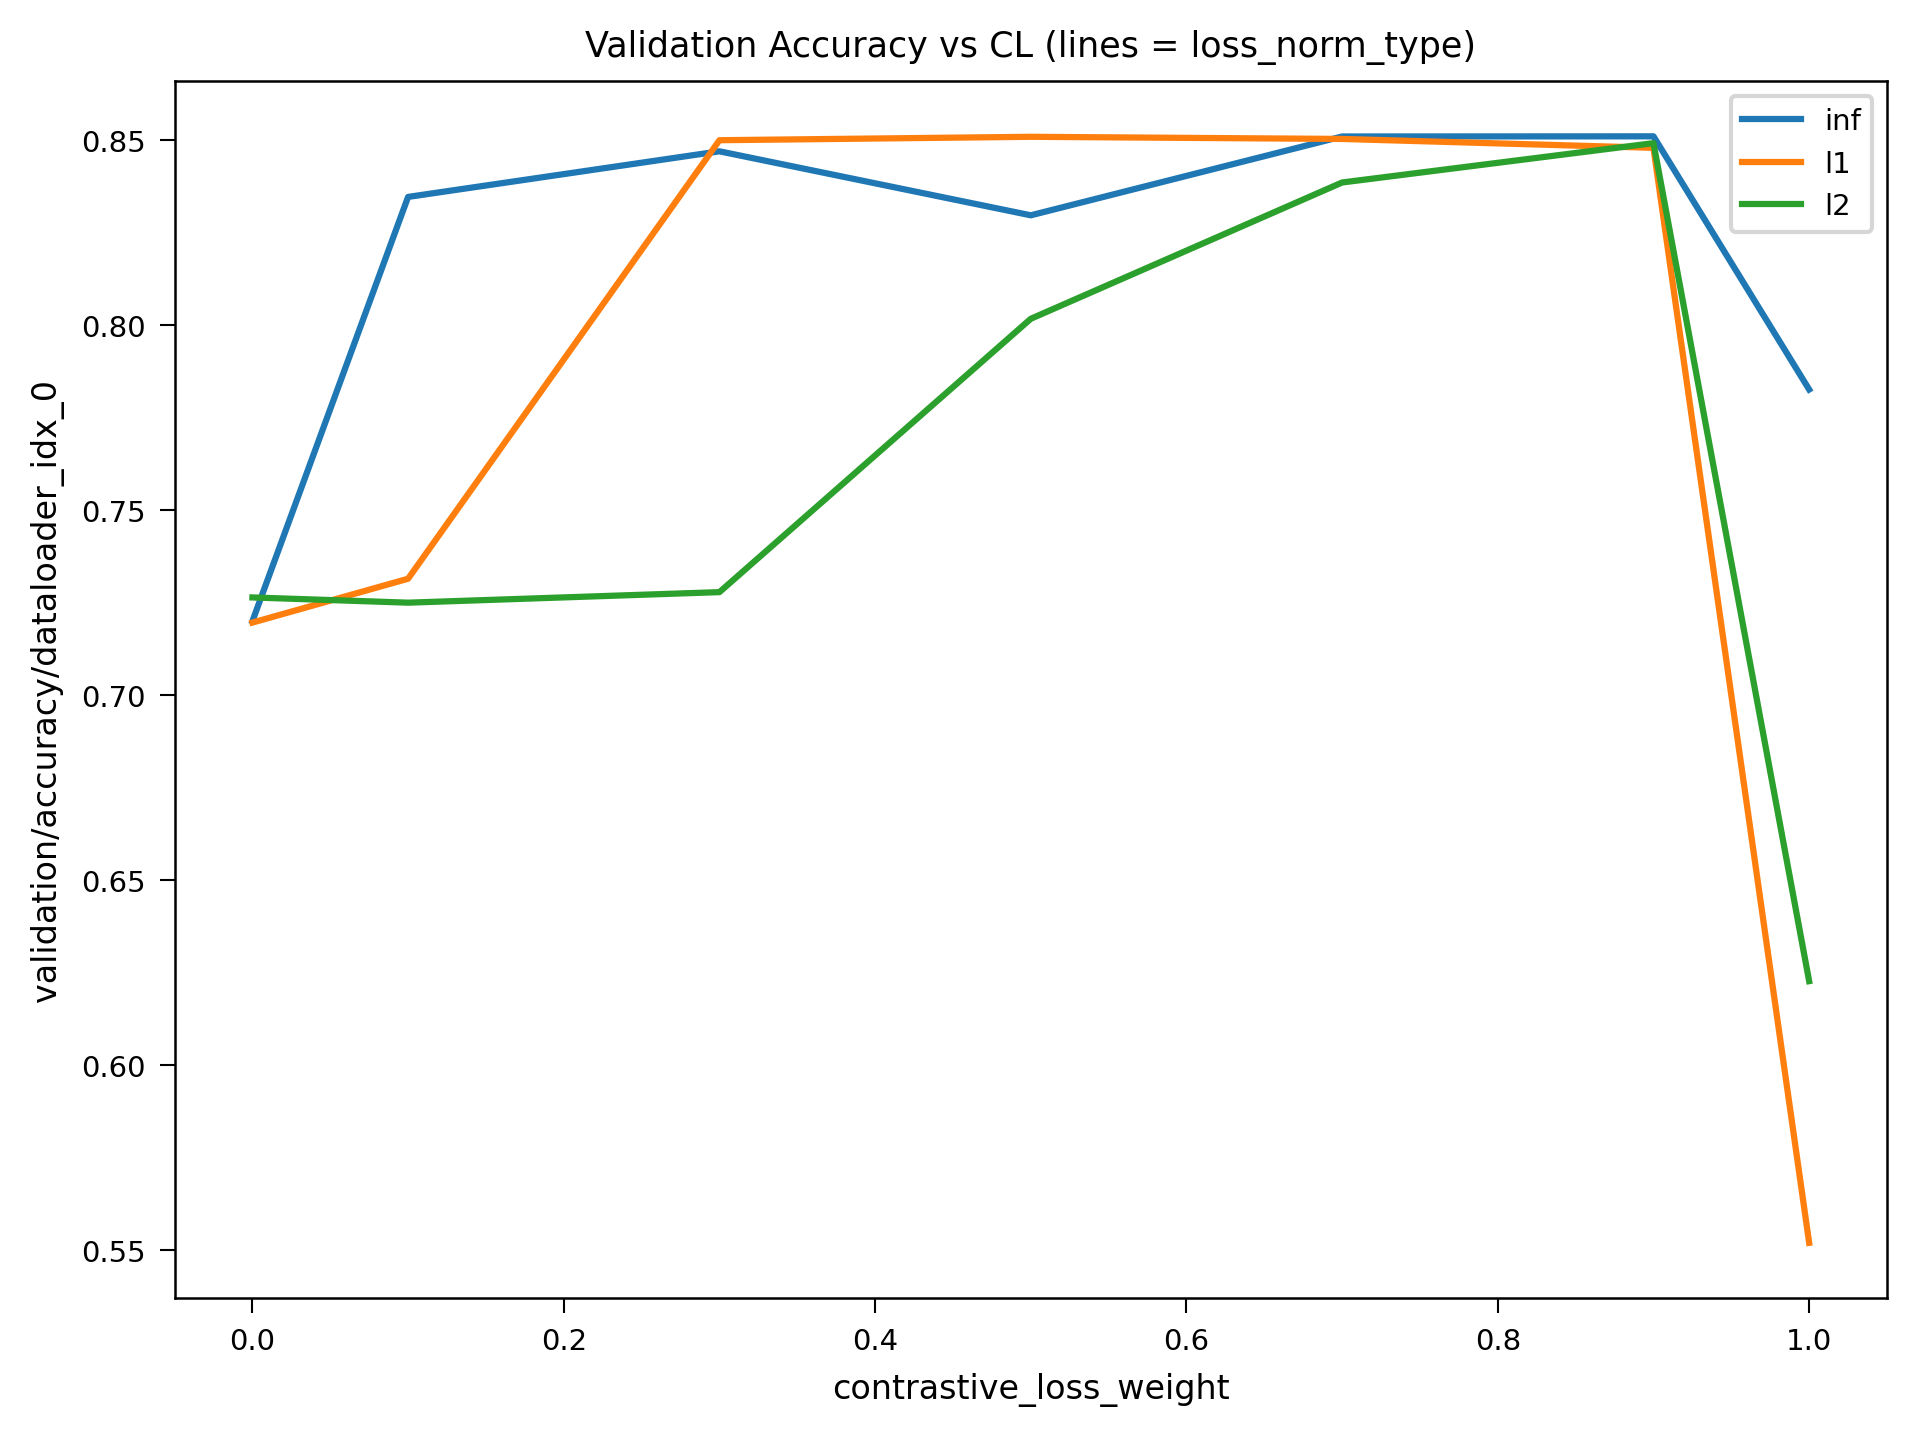

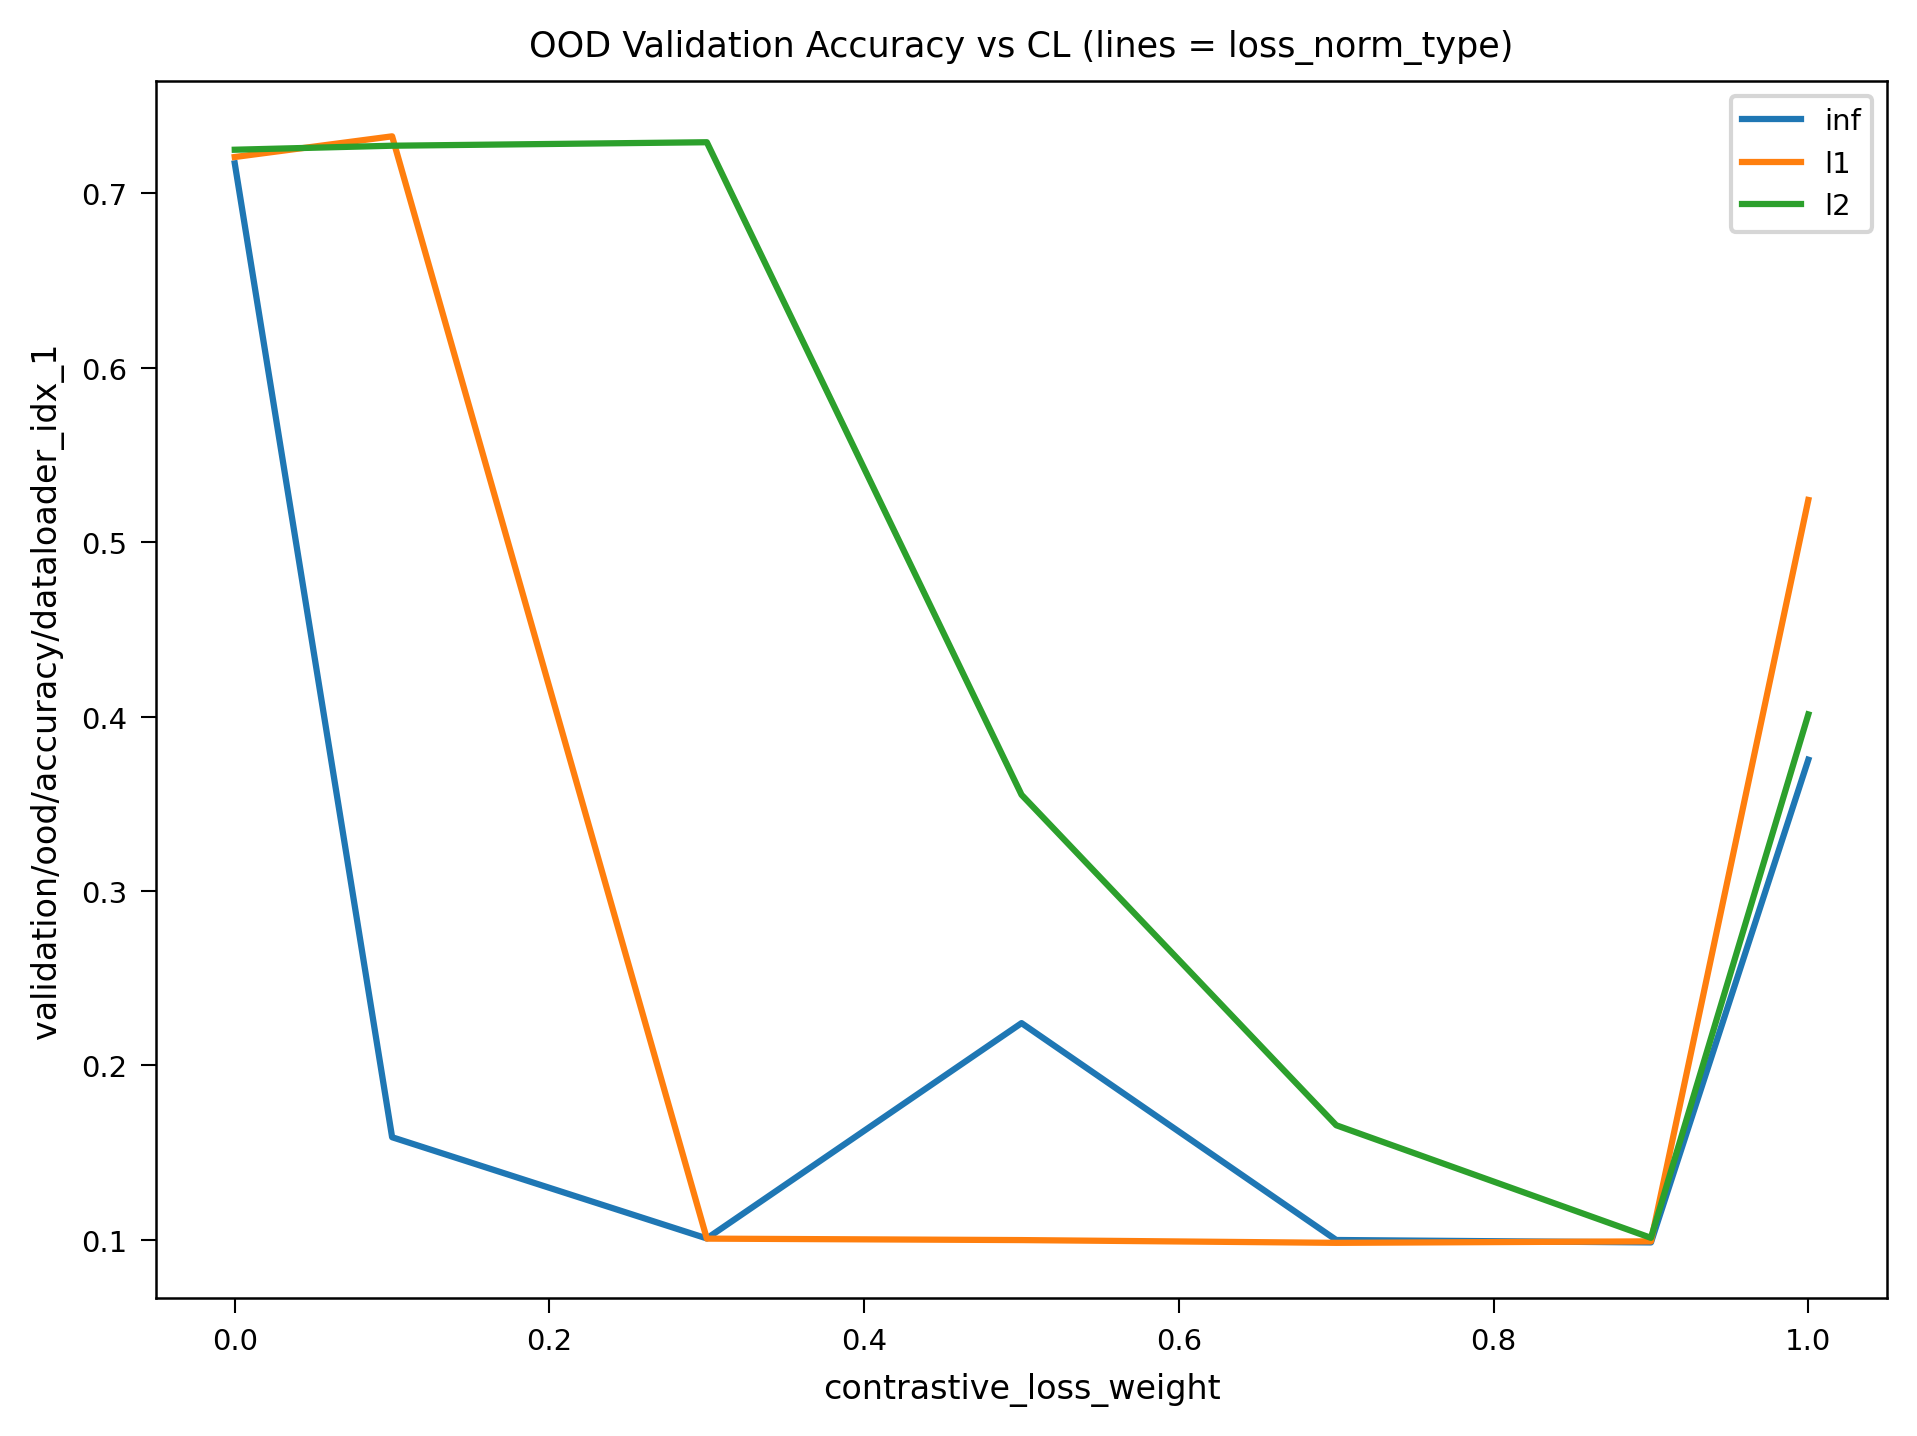

In [8]:
# Make the two requested charts: one for ID accuracy, one for OOD accuracy.
_plot_metric(agg, "validation/accuracy/dataloader_idx_0", title="Validation Accuracy vs CL (lines = loss_norm_type)")
_plot_metric(agg, "validation/ood/accuracy/dataloader_idx_1", title="OOD Validation Accuracy vs CL (lines = loss_norm_type)")


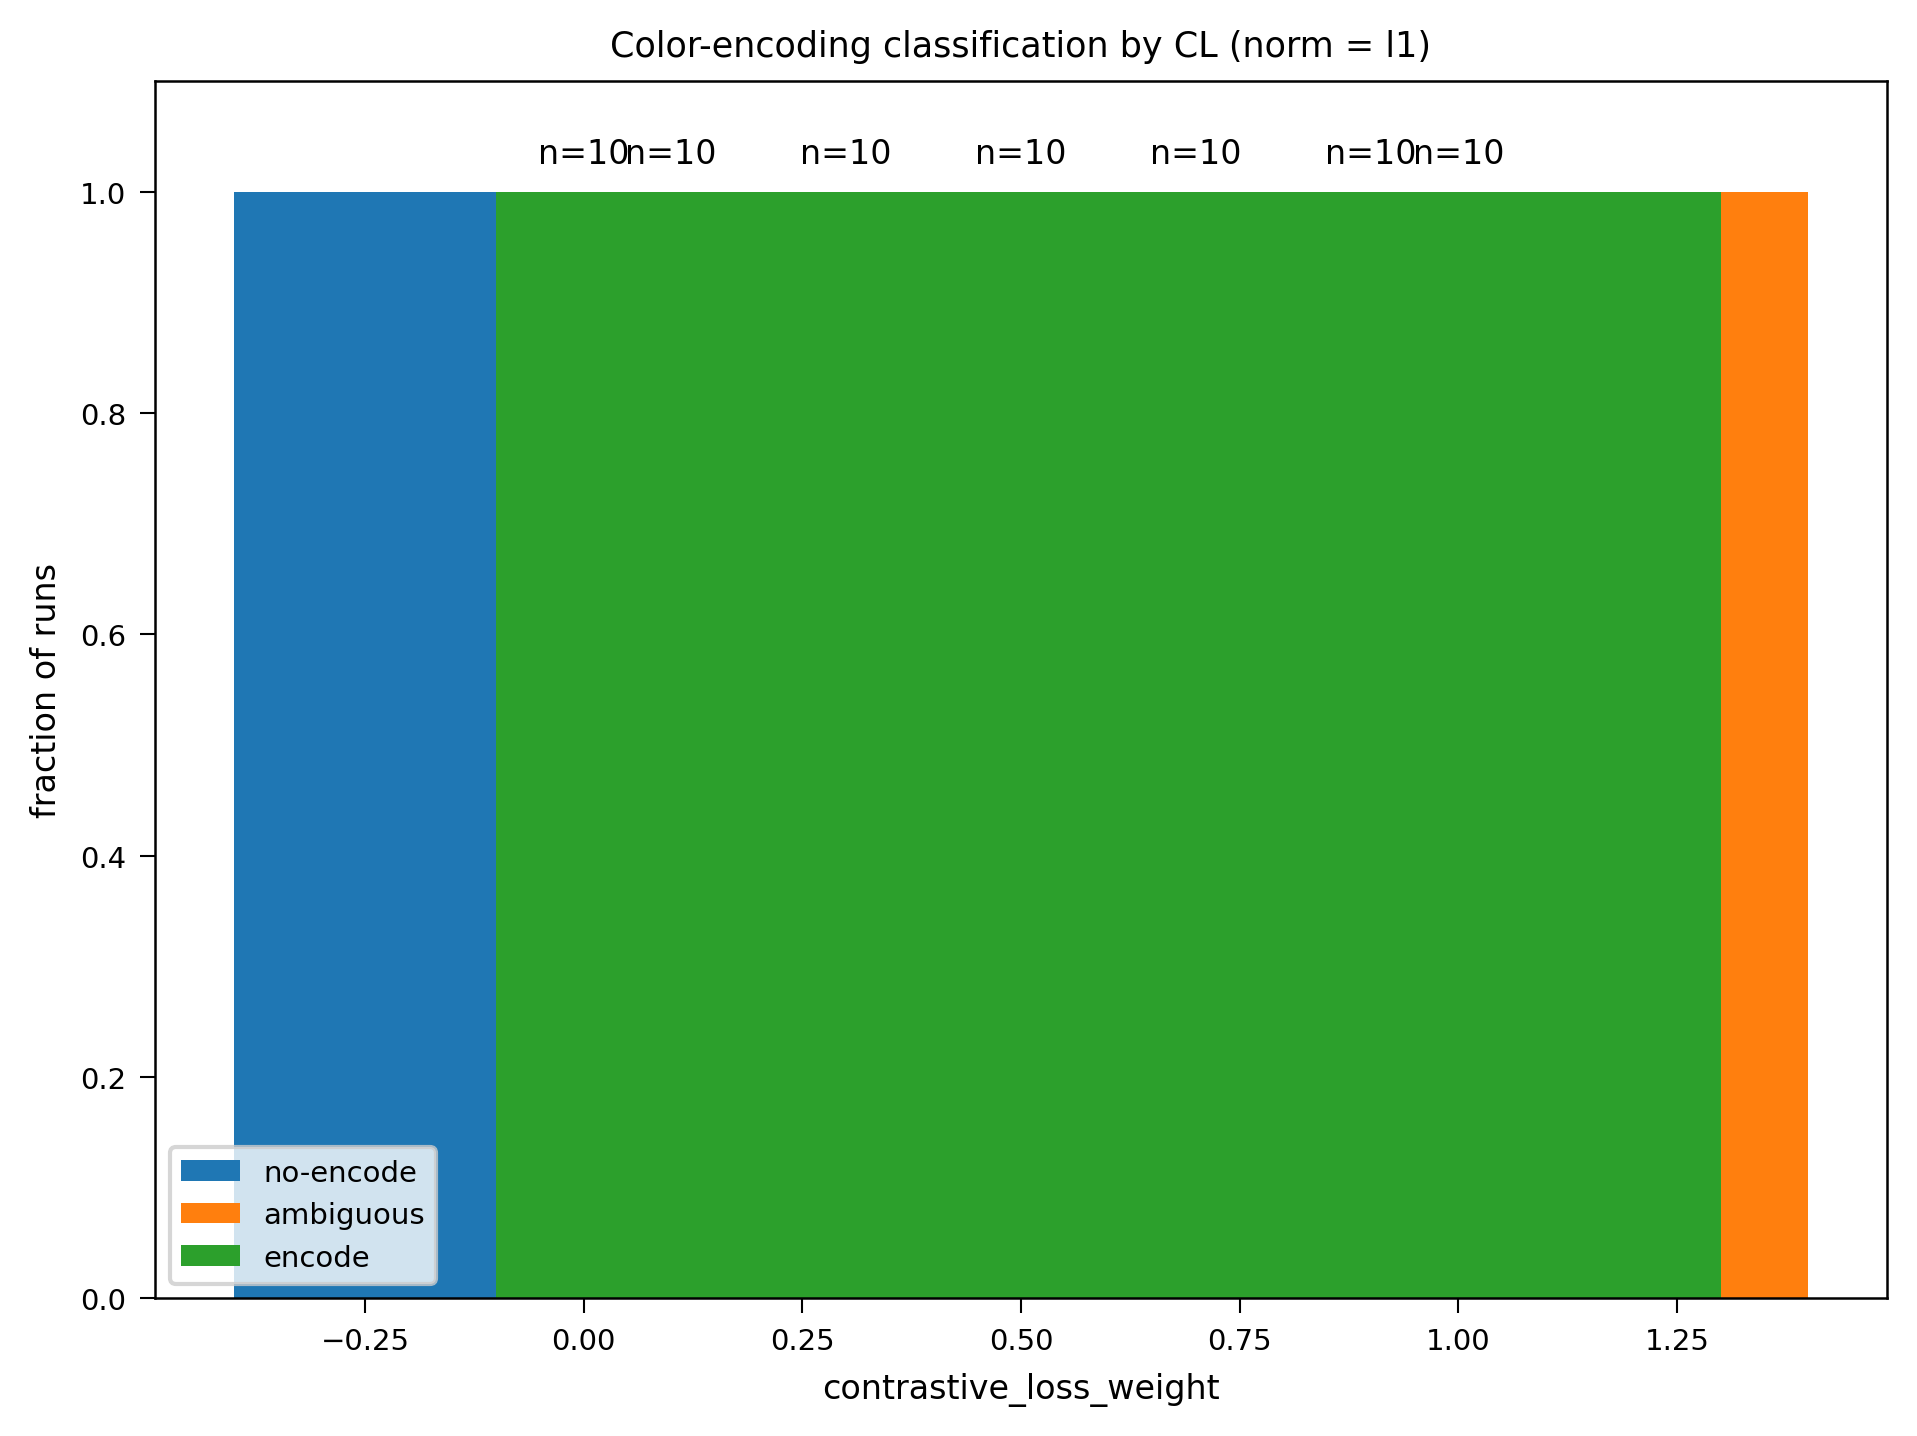

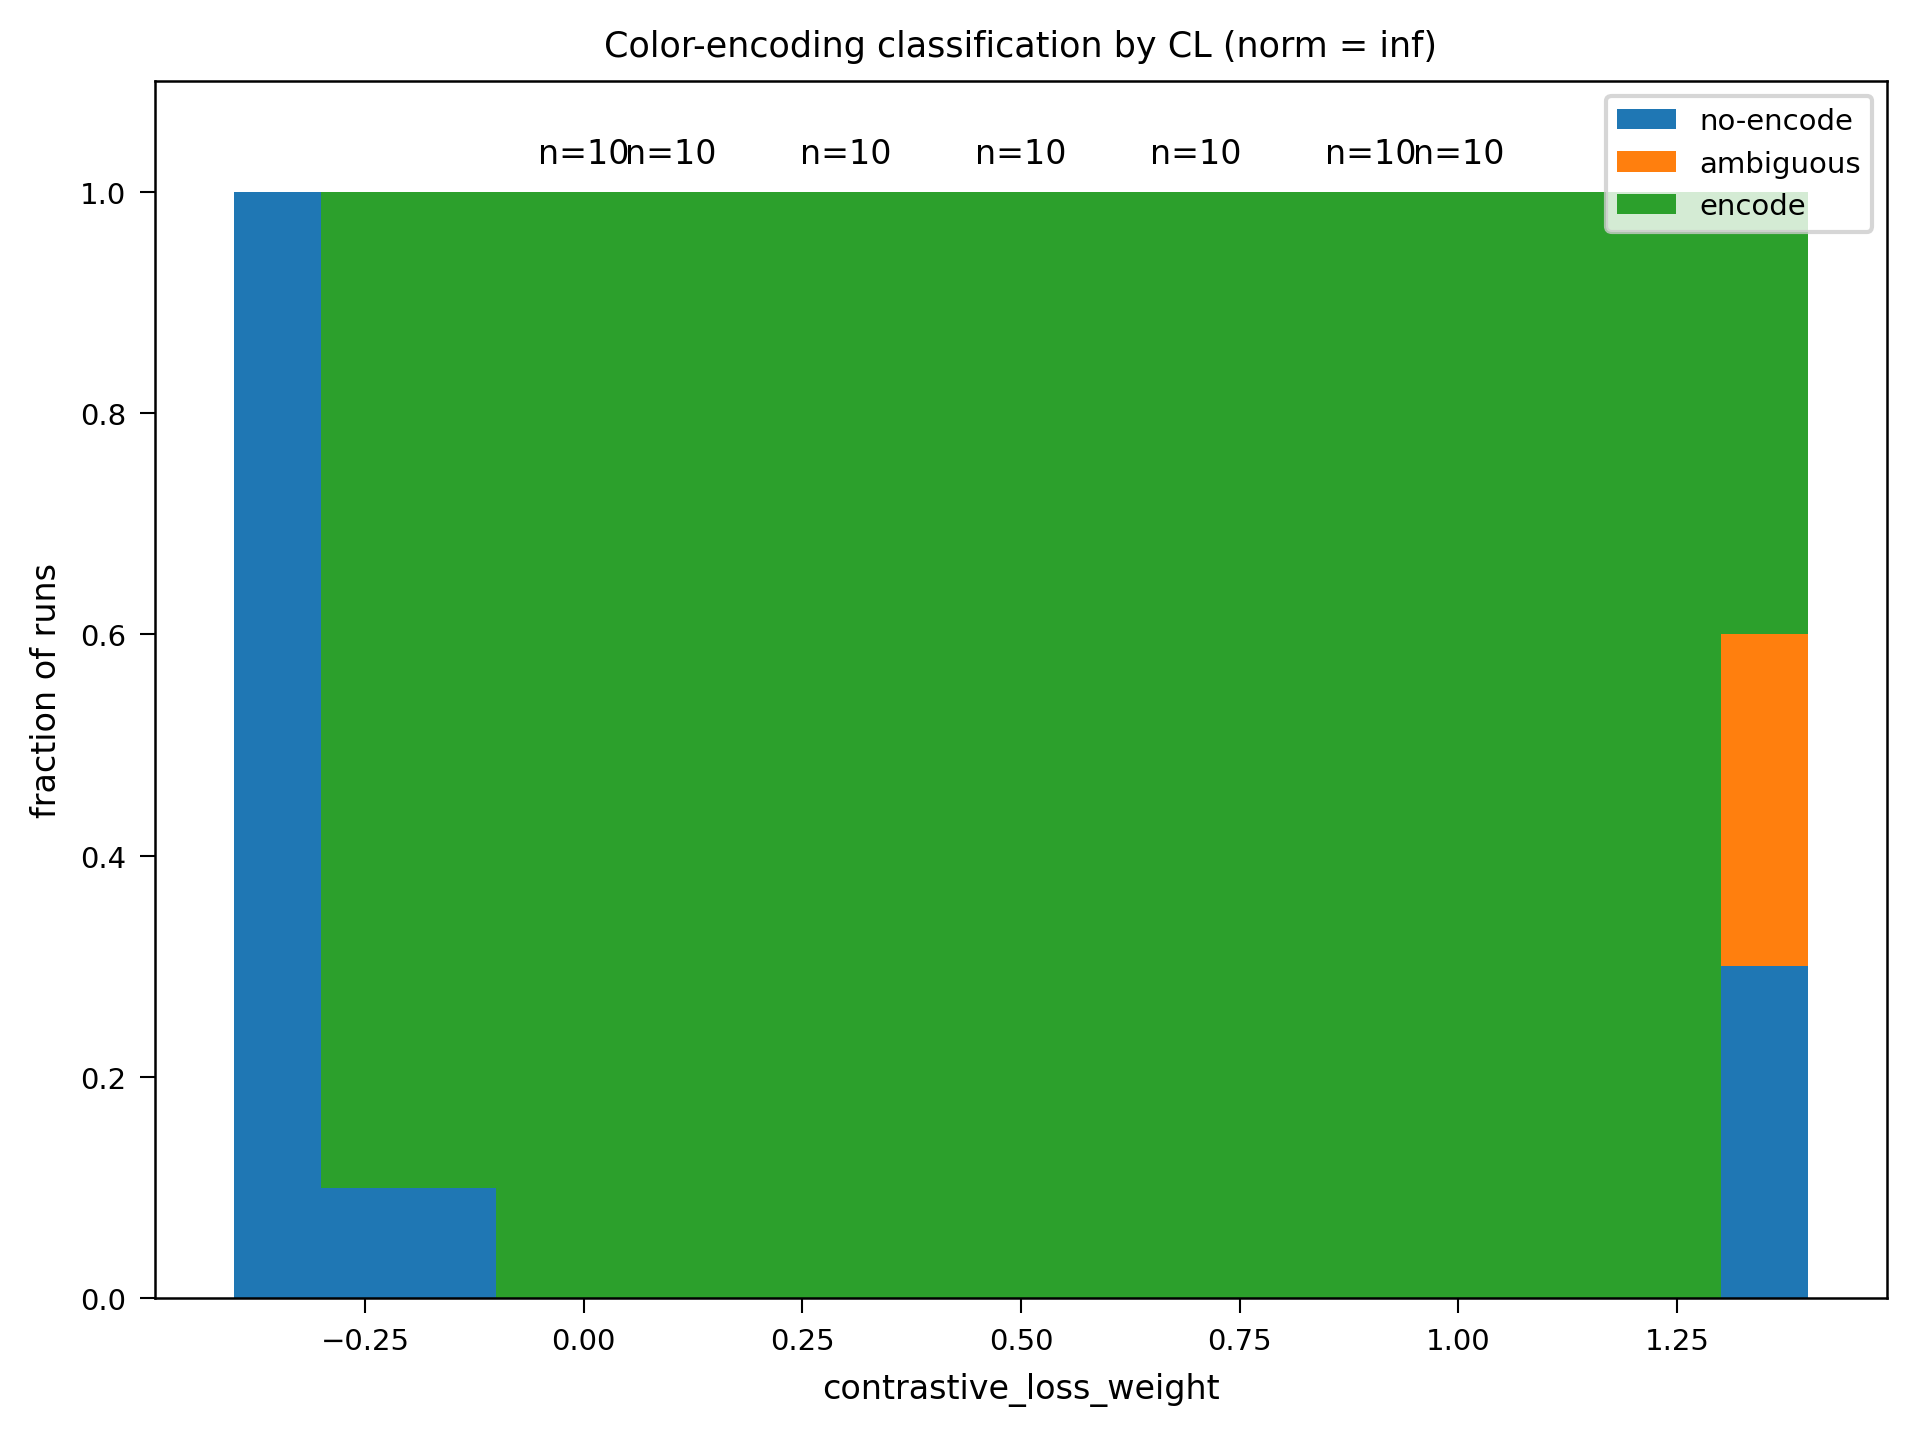

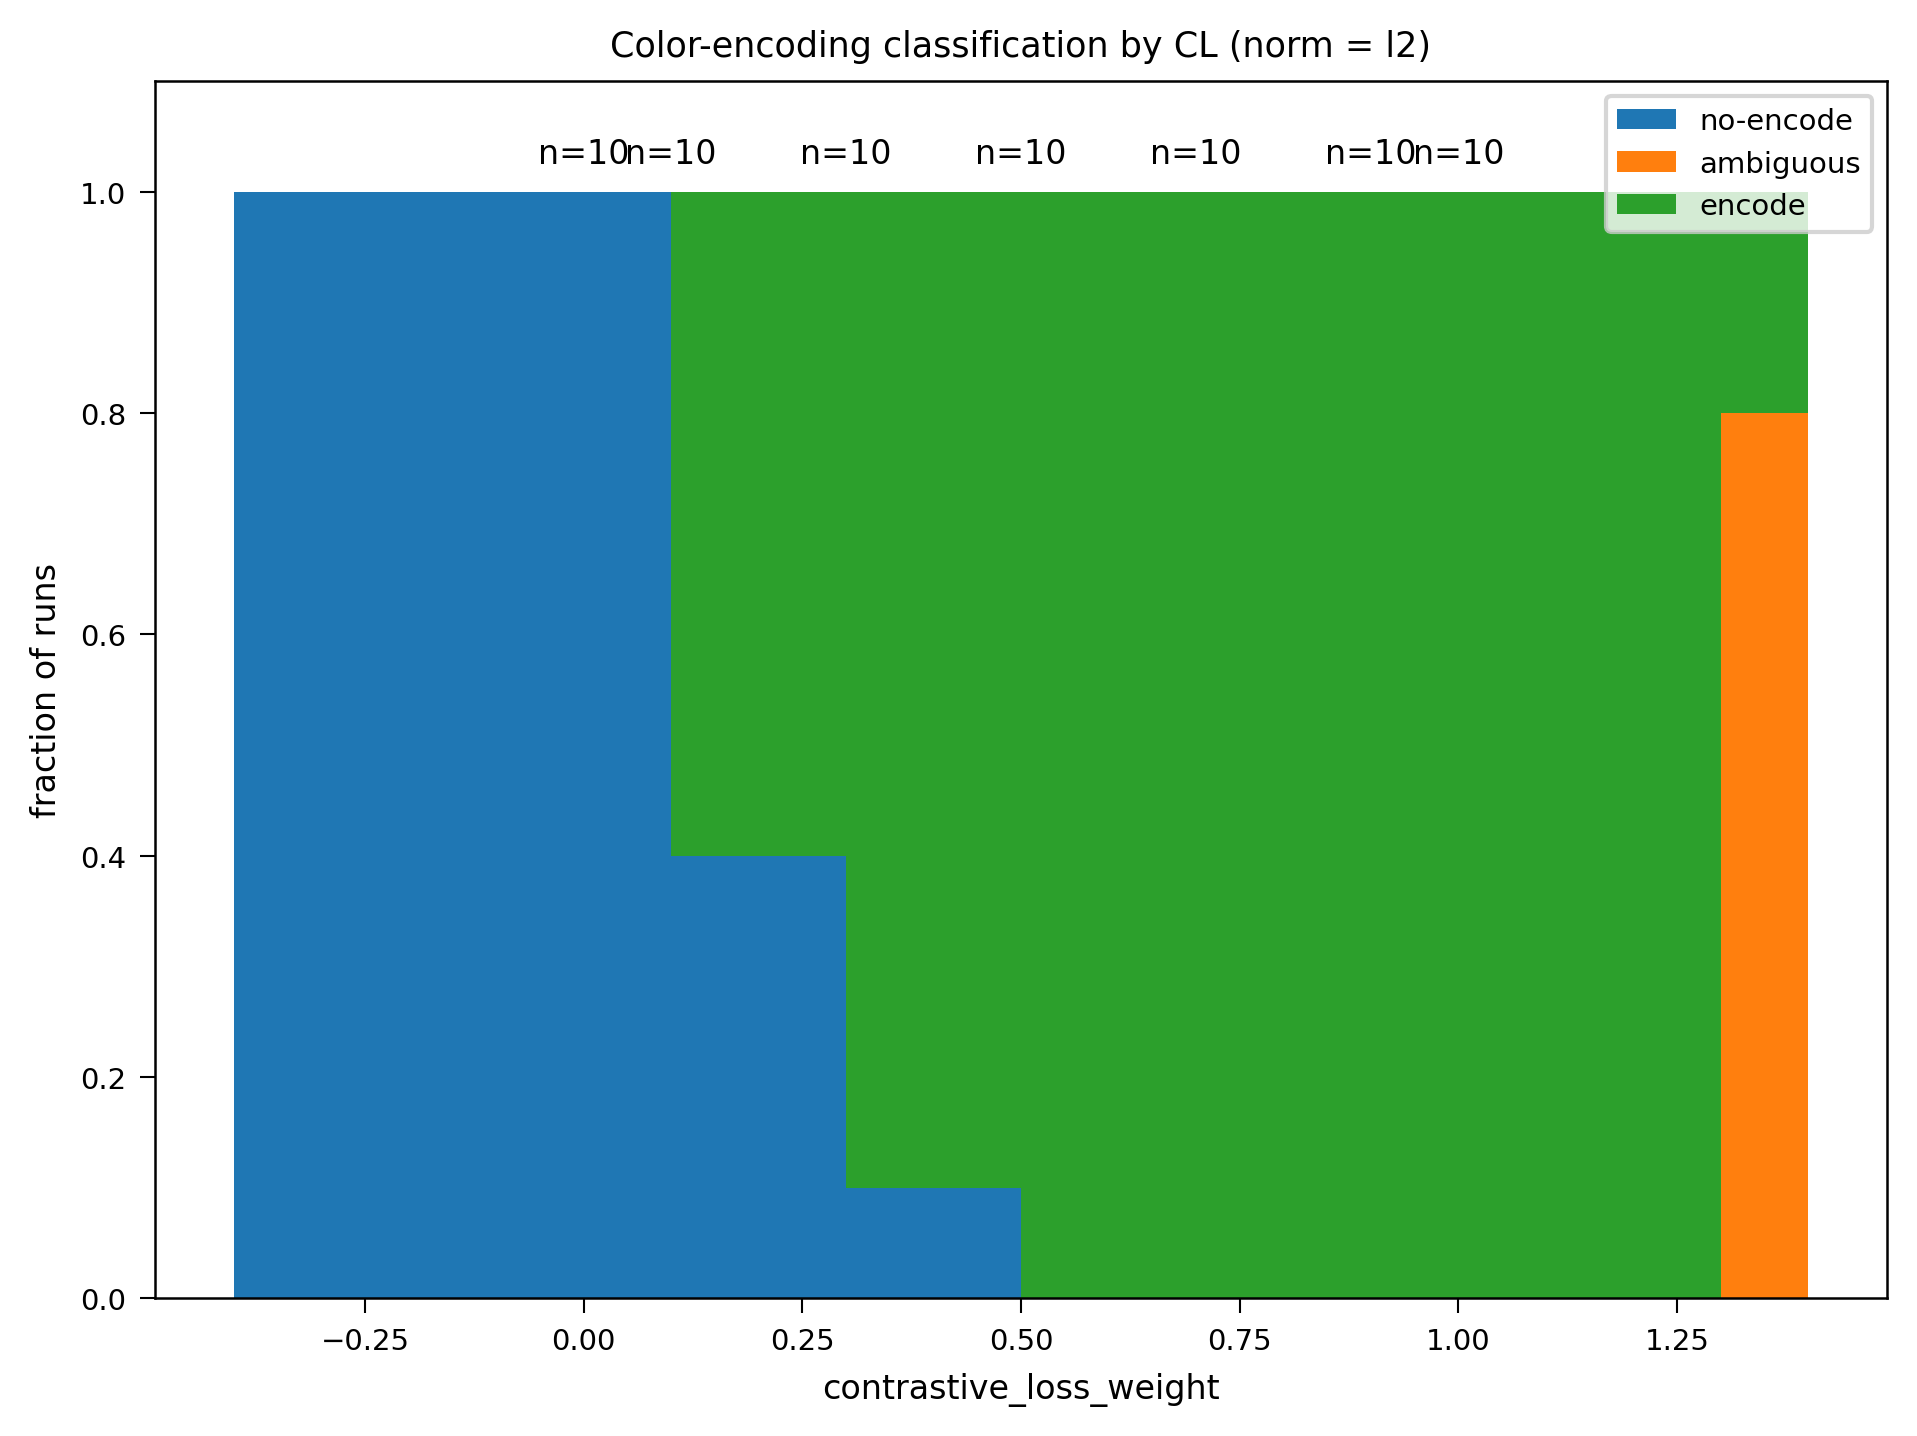

{'saved': ['schematic_color_encoding_l1.png',
  'schematic_color_encoding_inf.png',
  'schematic_color_encoding_l2.png'],
 'norms_plotted': ['l1', 'inf', 'l2']}

In [9]:
# Build a simple schematic from the already-built `agg` to show whether color is encoded,
# and with what uncertainty, as a function of contrastive_loss_weight (CL).
#
# Visualization choice here: stacked proportion bars per norm.
# - X axis: CL values
# - Y axis: fraction of runs
# - Stacks: {no-encode, ambiguous, encode}
# This yields an immediate "traffic light"-style read-out of consensus + uncertainty.
#
# Note: We do NOT set explicit colors (matplotlib will pick defaults). One figure per norm.

import json
import math
import os
from typing import Dict, Any, List, Tuple

import matplotlib.pyplot as plt

AGG_JSON = "aggregated_accuracy_by_norm_and_cl.json"

# 1) Load `agg` from memory if available, else from JSON
try:
    agg  # type: ignore[name-defined]
except NameError:
    with open(AGG_JSON, "r", encoding="utf-8") as f:
        agg = json.load(f)

# JSON may have string keys for CL; convert to float
agg_float: Dict[str, Dict[float, Dict[str, List[float]]]] = {}
for norm, cl_map in agg.items():
    agg_float[norm] = {}
    for cl_key, vals in cl_map.items():
        try:
            cl = float(cl_key)
        except Exception:
            # keep non-numeric keys out
            continue
        # ensure lists are floats
        out_entry = {}
        for k, arr in vals.items():
            out_entry[k] = [float(x) for x in arr if isinstance(x, (int, float)) or (isinstance(x, str) and x.replace('.','',1).isdigit())]
        agg_float[norm][cl] = out_entry

# 2) Classification thresholds (inclusive)
ID_ENCODE = (0.80, 0.865)
OOD_ENCODE = (0.09, 0.115)
NOENCODE = (0.68, 0.755)

def in_range(x: float, lo: float, hi: float) -> bool:
    return (x is not None) and (lo <= x <= hi)

def classify_pair(id_acc: float, ood_acc: float) -> str:
    if in_range(id_acc, *ID_ENCODE) and in_range(ood_acc, *OOD_ENCODE):
        return "encode"
    if in_range(id_acc, *NOENCODE) and in_range(ood_acc, *NOENCODE):
        return "no-encode"
    return "ambiguous"

# 3) Compute proportions per (norm, cl)
proportions: Dict[str, Dict[float, Dict[str, float]]] = {}
counts: Dict[str, Dict[float, int]] = {}

for norm, cl_map in agg_float.items():
    proportions[norm] = {}
    counts[norm] = {}
    for cl, vals in cl_map.items():
        id_list = vals.get("validation/accuracy/dataloader_idx_0", [])
        ood_list = vals.get("validation/ood/accuracy/dataloader_idx_1", [])
        n = min(len(id_list), len(ood_list))
        enc = amb = noenc = 0
        for i in range(n):
            label = classify_pair(id_list[i], ood_list[i])
            if label == "encode":
                enc += 1
            elif label == "no-encode":
                noenc += 1
            else:
                amb += 1
        total = max(n, 1)
        proportions[norm][cl] = {
            "no-encode": noenc / total,
            "ambiguous": amb / total,
            "encode": enc / total,
        }
        counts[norm][cl] = n

# 4) Plot: stacked proportion bars for each norm
out_paths = []
for norm, cl_map in proportions.items():
    if not cl_map:
        continue
    xs = sorted(cl_map.keys())
    cats = ["no-encode", "ambiguous", "encode"]
    bottoms = [0.0] * len(xs)

    plt.figure()
    for cat in cats:
        ys = [cl_map[x][cat] for x in xs]
        plt.bar(xs, ys, bottom=bottoms, label=cat)
        bottoms = [b + y for b, y in zip(bottoms, ys)]

    # annotate with N for context
    for xi, x in enumerate(xs):
        plt.text(x, 1.02, f"n={counts[norm][x]}", ha="center", va="bottom", fontsize=8, rotation=0)

    plt.ylim(0, 1.1)
    plt.xlabel("contrastive_loss_weight")
    plt.ylabel("fraction of runs")
    plt.title(f"Color-encoding classification by CL (norm = {norm})")
    plt.legend()
    plt.tight_layout()

    out_file = f"schematic_color_encoding_{norm}.png"
    plt.savefig(out_file, dpi=150)
    out_paths.append(out_file)
    plt.show()

# Return a tiny summary + the paths of saved images
{"saved": out_paths, "norms_plotted": list(proportions.keys())}


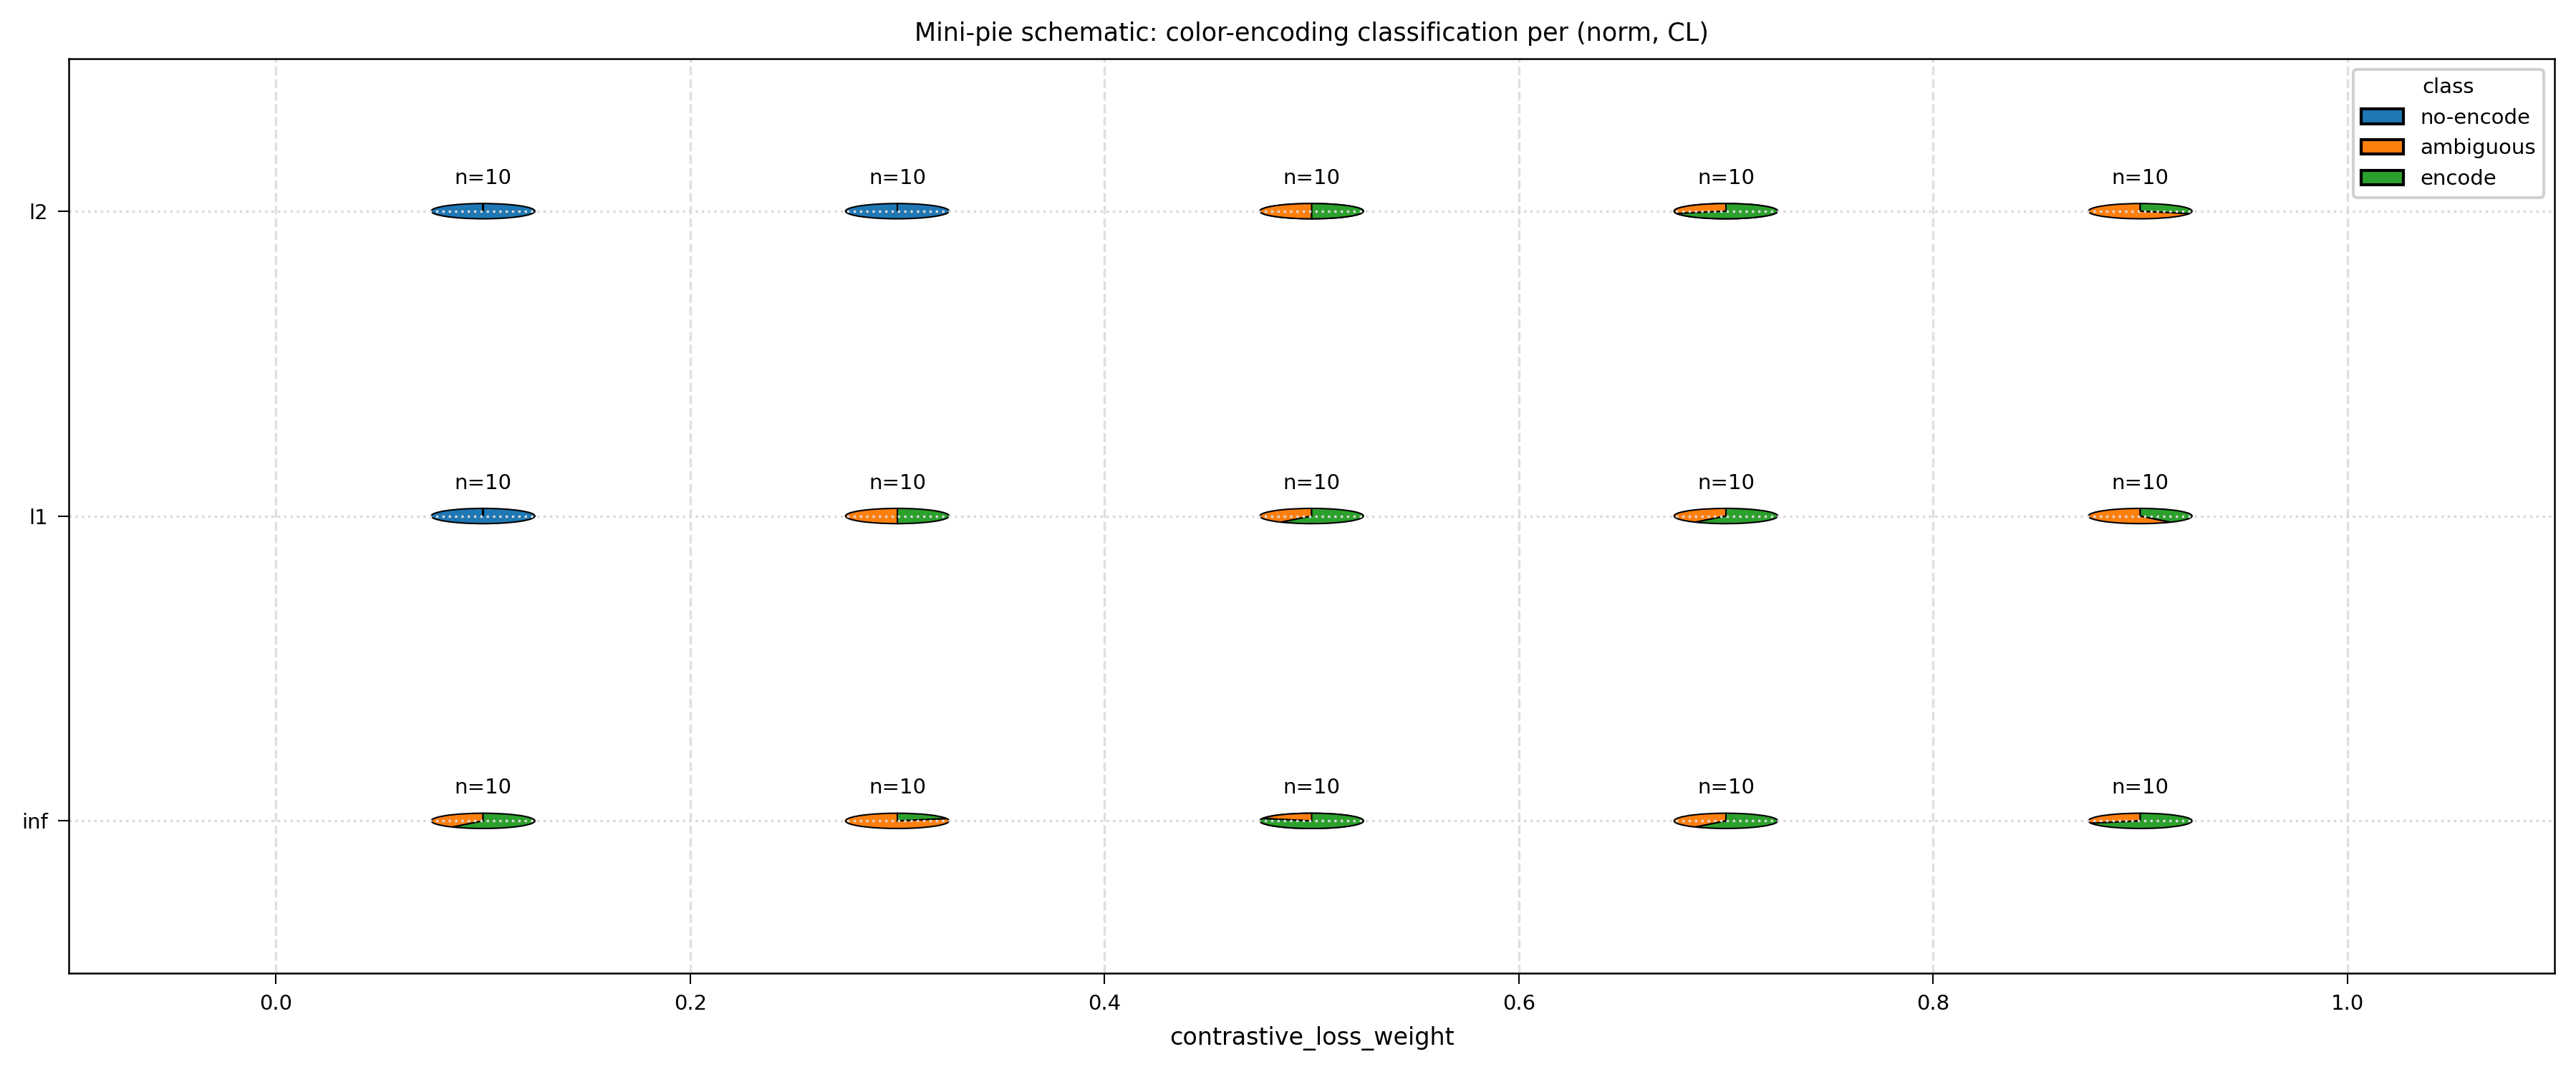

{'saved': ['mini_pie_grid.png'],
 'note': 'Each (norm, CL) cell is a mini pie with default matplotlib colors for N/A/E.'}

In [10]:
# Create a single-axes "mini pie chart grid" where each (norm, CL) cell contains
# a tiny pie showing the split across {no-encode, ambiguous, encode}.
# Uses the uploaded agg JSON file.
#
# Note: We rely on Matplotlib's default color cycle for consistent class colors.
# We access the default colors from rcParams to assign the same three defaults
# across all pies (no custom palette).
#
# One figure; no seaborn; no subplots.

import json
import math
from typing import Dict, List, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Patch

AGG_PATH = "aggregated_accuracy_by_norm_and_cl.json"

with open(AGG_PATH, "r", encoding="utf-8") as f:
    agg = json.load(f)

# Order norms and CLs
preferred_norm_order = ["inf", "l1", "l2"]
norms = [n for n in preferred_norm_order if n in agg] + [n for n in agg if n not in preferred_norm_order]
all_cls = sorted({float(c) for n in norms for c in agg[n].keys()})

# Classify by rule bands
ID_ENCODE = (0.80, 0.85)
OOD_ENCODE = (0.09, 0.12)
NOENCODE = (0.70, 0.75)

def in_range(x: float, lo: float, hi: float) -> bool:
    return lo <= x <= hi

def classify_pair(id_acc: float, ood_acc: float) -> str:
    if in_range(id_acc, *ID_ENCODE) and in_range(ood_acc, *OOD_ENCODE):
        return "encode"
    if in_range(id_acc, *NOENCODE) and in_range(ood_acc, *NOENCODE):
        return "no-encode"
    return "ambiguous"

classes = ["no-encode", "ambiguous", "encode"]

# Compute fractions per cell
fractions: Dict[Tuple[str, float], List[float]] = {}
counts: Dict[Tuple[str, float], int] = {}

for norm in norms:
    for cl in all_cls:
        cell = agg[norm].get(str(cl))
        if not cell:
            continue
        ids = cell.get("validation/accuracy/dataloader_idx_0", [])
        oods = cell.get("validation/ood/accuracy/dataloader_idx_1", [])
        n = min(len(ids), len(oods))
        counts[(norm, cl)] = n
        if n == 0:
            fractions[(norm, cl)] = [0.0, 0.0, 0.0]
            continue
        tallies = {"no-encode": 0, "ambiguous": 0, "encode": 0}
        for i in range(n):
            tallies[classify_pair(ids[i], oods[i])] += 1
        fracs = [tallies[c] / n for c in classes]
        fractions[(norm, cl)] = fracs

# Prepare figure / axes
fig, ax = plt.subplots(figsize=(12, 5))

# Axes scale: x = CL values (numeric), y = categorical indices (0..len(norms)-1)
y_positions = {norm: i for i, norm in enumerate(norms)}
ax.set_xlim(min(all_cls) - 0.1, max(all_cls) + 0.1)
ax.set_ylim(-0.5, len(norms) - 0.5)
ax.set_xlabel("contrastive_loss_weight")
ax.set_yticks(list(y_positions.values()), list(norms))
ax.set_title("Mini-pie schematic: color-encoding classification per (norm, CL)")

# Compute an appropriate pie radius in data units
# Use ~30% of the smaller gap: min delta in CL and 1.0 in Y
if len(all_cls) > 1:
    min_dx = min(abs(all_cls[i+1] - all_cls[i]) for i in range(len(all_cls)-1))
else:
    min_dx = 1.0
radius_x = 0.25 * min_dx
radius_y = 0.25 * 1.0
radius = min(radius_x, radius_y)

# Use default matplotlib colors (no custom palette)
default_colors = mpl.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2'])
class_colors = {
    "no-encode": default_colors[0 % len(default_colors)],
    "ambiguous": default_colors[1 % len(default_colors)],
    "encode": default_colors[2 % len(default_colors)],
}

# Helper: draw a pie with wedges at (x, y)
def draw_mini_pie(ax, x, y, fracs, radius, edgecolor="black", linewidth=0.5):
    start_angle = 90  # start at 12 o'clock
    for cls, frac in zip(classes, fracs):
        if frac <= 0:
            continue
        theta = frac * 360.0
        wedge = Wedge(center=(x, y), r=radius, theta1=start_angle, theta2=start_angle - theta,
                      facecolor=class_colors[cls], edgecolor=edgecolor, linewidth=linewidth)
        ax.add_patch(wedge)
        start_angle -= theta

# Draw pies on the grid
for norm in norms:
    y = y_positions[norm]
    for cl in all_cls:
        fracs = fractions.get((norm, cl))
        if fracs is None:
            continue
        draw_mini_pie(ax, cl, y, fracs, radius)
        # annotate n on top of pie
        n = counts.get((norm, cl), 0)
        ax.text(cl, y + radius + 0.05, f"n={n}", ha="center", va="bottom", fontsize=7)

# Grid styling
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
for y in y_positions.values():
    ax.axhline(y, color="0.85", linestyle=":", linewidth=0.8)

# Legend using default colors
handles = [Patch(facecolor=class_colors[c], edgecolor="black", label=c) for c in classes]
ax.legend(handles=handles, title="class", loc="upper right", framealpha=0.9)

plt.tight_layout()
out = "mini_pie_grid.png"
plt.savefig(out, dpi=150)
plt.show()

{"saved": [out], "note": "Each (norm, CL) cell is a mini pie with default matplotlib colors for N/A/E."}


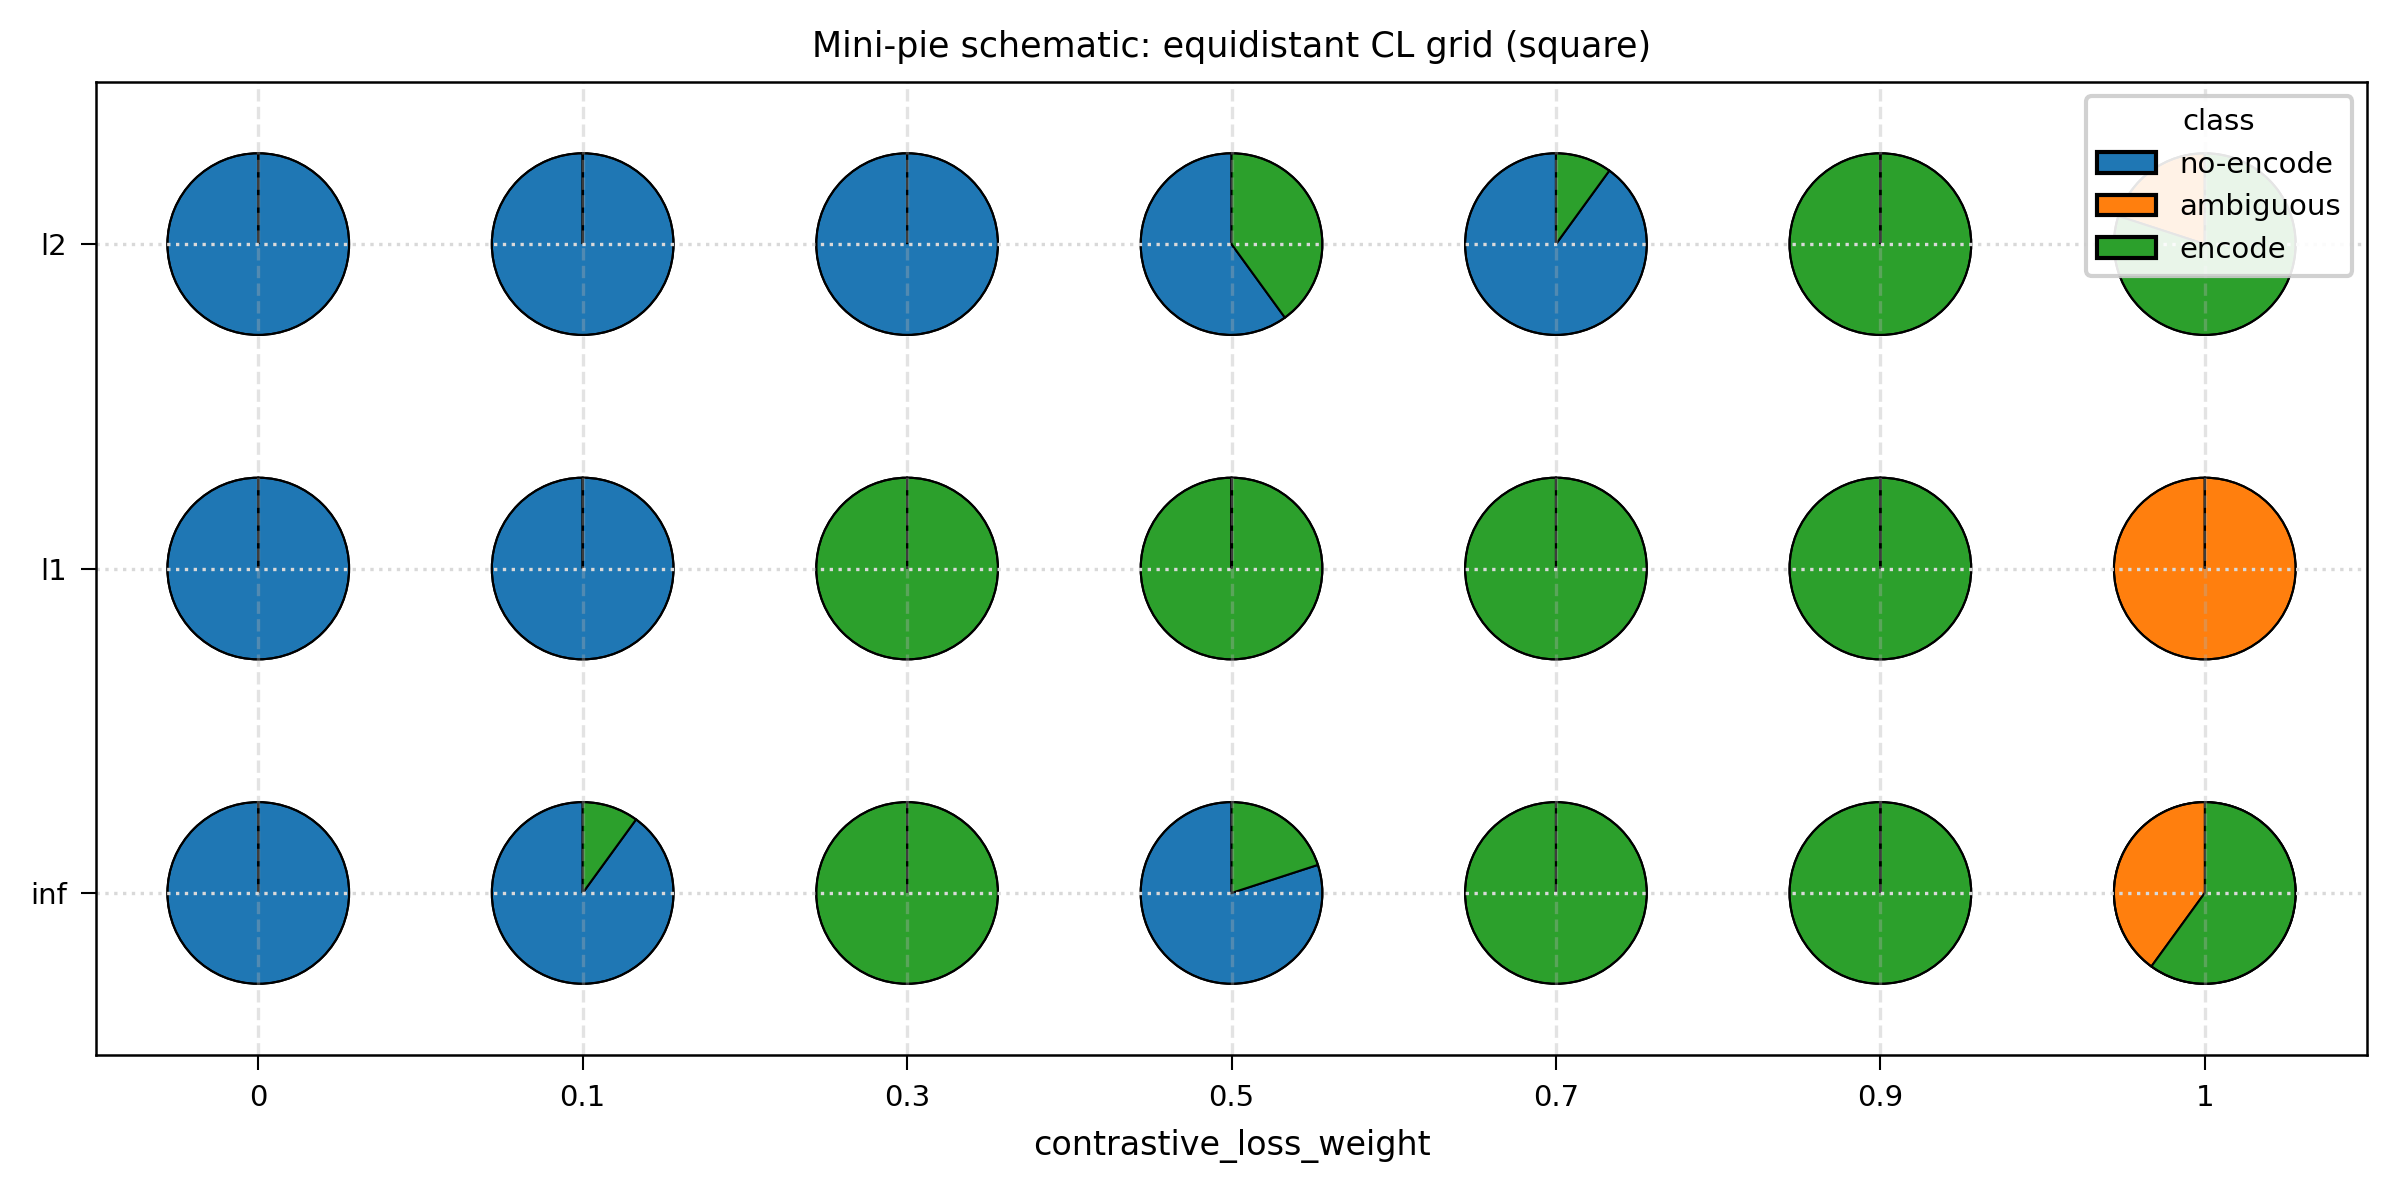

{'saved': ['mini_pie_grid_square_equidistant.png']}

In [11]:
# Mini-pie grid: equidistant CL positions on a regular grid, square figure.
# - Ignore the numeric spacing of CL; place them at integer positions 0..N-1.
# - Keep pies perfectly circular via equal aspect.
# - Square canvas (e.g., 8x8).

import json
from typing import Dict, List, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Patch

AGG_PATH = "aggregated_accuracy_by_norm_and_cl.json"
with open(AGG_PATH, "r", encoding="utf-8") as f:
    agg = json.load(f)

# Order norms and CLs
preferred_norm_order = ["inf", "l1", "l2"]
norms = [n for n in preferred_norm_order if n in agg] + [n for n in agg if n not in preferred_norm_order]

# Unique CLs across norms (as floats) for labeling; we will place them at 0..N-1
all_cls = sorted({float(k) for n in norms for k in agg[n].keys()})

def fmt_key(x: float) -> str:
    return format(x, 'g')  # ensures '0', '1', '0.1', etc.

# Rule bands
ID_ENCODE = (0.80, 0.865)
OOD_ENCODE = (0.09, 0.115)
NOENCODE = (0.68, 0.755)

def in_range(x: float, lo: float, hi: float) -> bool:
    return lo <= x <= hi

def classify_pair(id_acc: float, ood_acc: float) -> str:
    if in_range(id_acc, *ID_ENCODE) and in_range(ood_acc, *OOD_ENCODE):
        return "encode"
    if in_range(id_acc, *NOENCODE) and in_range(ood_acc, *NOENCODE):
        return "no-encode"
    return "ambiguous"

classes = ["no-encode", "ambiguous", "encode"]

# Compute fractions per (norm, cl) with robust key formatting
fractions: Dict[Tuple[str, float], List[float]] = {}
for norm in norms:
    clmap = agg[norm]
    for cl in all_cls:
        cell = clmap.get(fmt_key(cl))
        if not cell:
            continue
        ids = cell.get("validation/accuracy/dataloader_idx_0", [])
        oods = cell.get("validation/ood/accuracy/dataloader_idx_1", [])
        n = min(len(ids), len(oods))
        if n == 0:
            continue
        tallies = {"no-encode": 0, "ambiguous": 0, "encode": 0}
        for i in range(n):
            tallies[classify_pair(ids[i], oods[i])] += 1
        fractions[(norm, cl)] = [tallies[c] / n for c in classes]

# Positions: equidistant integer grid along x
x_positions = {cl: i for i, cl in enumerate(all_cls)}
xtick_positions = list(x_positions.values())
xtick_labels = [fmt_key(cl) for cl in all_cls]

# Plot (square)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', adjustable='box')

y_positions = {norm: i for i, norm in enumerate(norms)}
ax.set_xlim(-0.5, len(all_cls) - 0.5)
ax.set_ylim(-0.5, len(norms) - 0.5)
ax.set_xlabel("contrastive_loss_weight")
ax.set_yticks(list(y_positions.values()), list(norms))
ax.set_xticks(xtick_positions, xtick_labels)
ax.set_title("Mini-pie schematic: equidistant CL grid (square)")

# Radius: safe fraction of grid cell; grid cell size is 1x1
radius = 0.28  # 28% of cell size; adjust if needed

default_colors = mpl.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2'])
class_colors = {"no-encode": default_colors[0], "ambiguous": default_colors[1], "encode": default_colors[2]}

def draw_mini_pie(ax, x, y, fracs, radius, edgecolor="black", linewidth=0.5):
    total = sum(fracs)
    if total <= 0:
        return
    fracs = [f/total for f in fracs]
    start_angle = 90
    for cls, frac in zip(classes, fracs):
        if frac <= 0:
            continue
        theta = frac * 360.0
        wedge = Wedge(center=(x, y), r=radius, theta1=start_angle, theta2=start_angle - theta,
                      facecolor=class_colors[cls], edgecolor=edgecolor, linewidth=linewidth)
        ax.add_patch(wedge)
        start_angle -= theta
    ring = Circle((x, y), radius, fill=False, edgecolor='black', linewidth=0.5)
    ax.add_patch(ring)

# Draw pies on the regular grid
for norm in norms:
    y = y_positions[norm]
    for cl in all_cls:
        fracs = fractions.get((norm, cl))
        if fracs is None:
            continue
        x = x_positions[cl]
        draw_mini_pie(ax, x, y, fracs, radius)

# Grid styling on a regular lattice
ax.set_xticks(xtick_positions, xtick_labels)
ax.grid(True, axis="x", linestyle="--", alpha=0.35)
for y in y_positions.values():
    ax.axhline(y, color="0.85", linestyle=":", linewidth=0.8)

# Legend
handles = [Patch(facecolor=class_colors[c], edgecolor="black") for c in classes]
ax.legend(handles, classes, title="class", loc="upper right", framealpha=0.9)

plt.tight_layout()
out = "mini_pie_grid_square_equidistant.png"
plt.savefig(out, dpi=150)
plt.show()

{"saved": [out]}


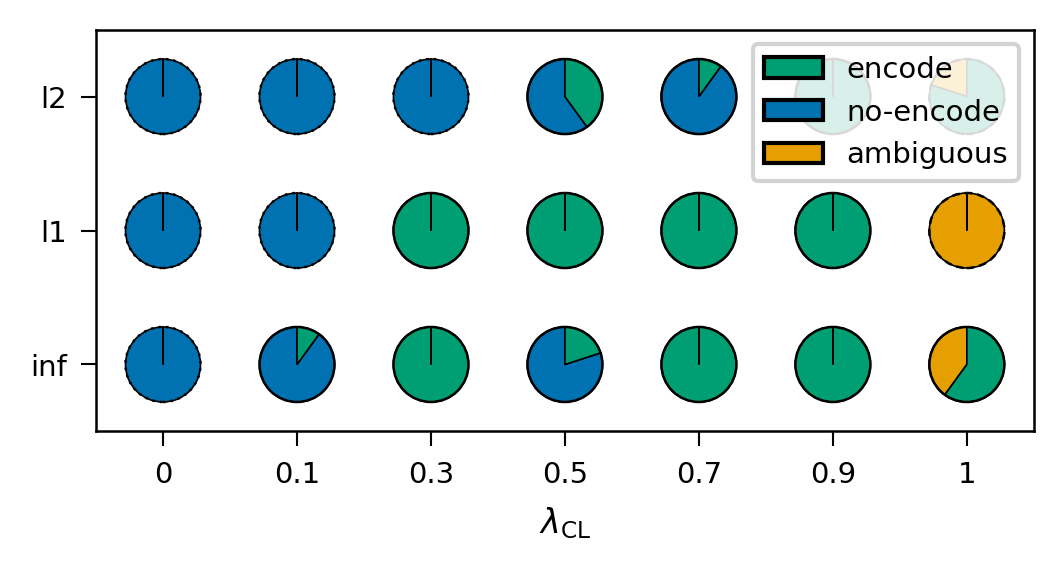

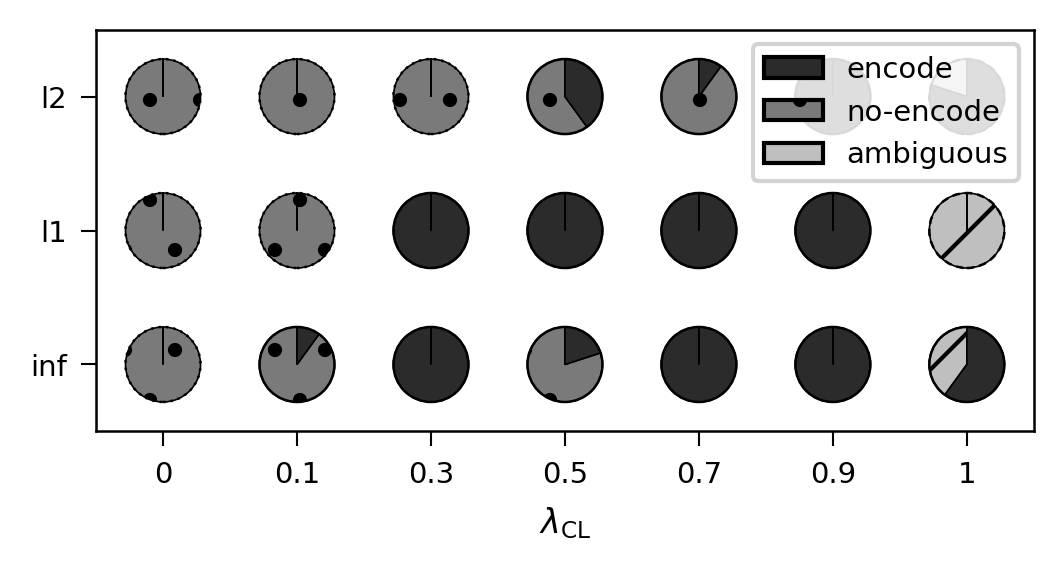

{'debug_num_cells': 21,
 'saved': ['mini_pie_neurips_color.png', 'mini_pie_neurips_mono.png']}

In [12]:
# NeurIPS-style mini-pie grid: equidistant CL positions, square figure, robust CL key handling.
# - Uses color-blind–safe palette (Okabe–Ito).
# - Also saves a monochrome+hatched version for print.
# - Font sizes tuned for one-column width (~3.35in).
#
# Input agg JSON: previously uploaded by user.

import json
from typing import Dict, List, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Patch

AGG_PATH = "aggregated_accuracy_by_norm_and_cl.json"
with open(AGG_PATH, "r", encoding="utf-8") as f:
    agg = json.load(f)

# ---- NeurIPS-ish styling ----
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Order norms and CLs
preferred_norm_order = ["inf", "l1", "l2"]
norms = [n for n in preferred_norm_order if n in agg] + [n for n in agg if n not in preferred_norm_order]

# Unique CLs across norms (numeric), but we will place them on an equidistant integer grid
all_cls = sorted({float(k) for n in norms for k in agg[n].keys()})

def fmt_key(x: float) -> str:
    return format(x, 'g')  # 0.0->'0', 1.0->'1', 0.10->'0.1'

# Rule bands
ID_ENCODE = (0.80, 0.865)
OOD_ENCODE = (0.09, 0.115)
NOENCODE = (0.68, 0.755)

def in_range(x: float, lo: float, hi: float) -> bool:
    return lo <= x <= hi

def classify_pair(id_acc: float, ood_acc: float) -> str:
    if in_range(id_acc, *ID_ENCODE) and in_range(ood_acc, *OOD_ENCODE):
        return "encode"
    if in_range(id_acc, *NOENCODE) and in_range(ood_acc, *NOENCODE):
        return "no-encode"
    return "ambiguous"

classes = ["no-encode", "ambiguous", "encode"]

# Compute fractions and majority per (norm, cl) with robust key formatting
fractions: Dict[Tuple[str, float], List[float]] = {}
majority: Dict[Tuple[str, float], str] = {}

for norm in norms:
    clmap = agg[norm]
    for cl in all_cls:
        cell = clmap.get(fmt_key(cl))
        if not cell:
            continue
        ids = cell.get("validation/accuracy/dataloader_idx_0", [])
        oods = cell.get("validation/ood/accuracy/dataloader_idx_1", [])
        n = min(len(ids), len(oods))
        if n == 0:
            continue
        tallies = {"no-encode": 0, "ambiguous": 0, "encode": 0}
        for i in range(n):
            tallies[classify_pair(ids[i], oods[i])] += 1
        fracs = [tallies[c] / n for c in classes]
        fractions[(norm, cl)] = fracs
        majority[(norm, cl)] = max(tallies.items(), key=lambda kv: kv[1])[0]

# If nothing was computed, bail early with a small printout to debug
debug_count = len(fractions)

# Equidistant grid positions
x_positions = {cl: i for i, cl in enumerate(all_cls)}
xtick_positions = list(x_positions.values())
xtick_labels = [fmt_key(cl) for cl in all_cls]
y_positions = {norm: i for i, norm in enumerate(norms)}

# Color-blind–safe palette (Okabe–Ito)
CLASS_COLORS = {
    "encode":    "#009E73",  # green
    "no-encode": "#0072B2",  # blue
    "ambiguous": "#E69F00",  # orange
}
# Redundant ring style by majority class
RING_STYLE = {
    "encode": (0.6, "solid"),
    "no-encode": (0.6, (0, (1, 2))),   # dotted
    "ambiguous": (0.6, (0, (3, 2))),   # dashed
}

def draw_mini_pie(ax, x, y, fracs, radius, majority_label=None):
    total = sum(fracs)
    if total <= 0:
        return
    fracs = [f/total for f in fracs]
    start_angle = 90
    order = ["no-encode", "ambiguous", "encode"]
    for cls, frac in zip(order, fracs):
        if frac <= 0:
            continue
        w = Wedge((x, y), radius, start_angle, start_angle - 360*frac,
                  facecolor=CLASS_COLORS[cls], edgecolor="black", linewidth=0.4)
        ax.add_patch(w)
        start_angle -= 360*frac
    # ring for redundancy
    if majority_label:
        lw, ls = RING_STYLE[majority_label]
    else:
        lw, ls = 0.6, "solid"
    ring = Circle((x, y), radius, fill=False, edgecolor="black", linewidth=lw, linestyle=ls)
    ax.add_patch(ring)

def make_figure(path, palette="color"):
    fig, ax = plt.subplots(figsize=(3.35, 3.35))  # one-column, square
    ax.set_aspect("equal", adjustable="box")

    # Bounds for a regular grid
    ax.set_xlim(-0.5, len(all_cls) - 0.5)
    ax.set_ylim(-0.5, len(norms) - 0.5)

    # Labels
    ax.set_xlabel(r"$\lambda_{\mathrm{CL}}$")
    ax.set_yticks(list(y_positions.values()), list(norms))

    # Pie radius: fraction of cell (cell is 1x1)
    radius = 0.28
    #for y in y_positions.values():
    #    ax.axhline(y, color="0.85", linestyle=":", linewidth=0.8)
    # Draw pies
    for norm in norms:
        y = y_positions[norm]
        for cl in all_cls:
            key = (norm, cl)
            if key not in fractions:
                continue
            draw_mini_pie(ax, x_positions[cl], y, fractions[key], radius, majority_label=majority.get(key))

    # Subtle grid
    ax.set_xticks(xtick_positions, xtick_labels)
    #ax.grid(True, axis="x", linestyle="--", alpha=0.25)


    # Legend
    handles = [Patch(facecolor=CLASS_COLORS[k], edgecolor="black", label=k) for k in ["encode","no-encode","ambiguous"]]
    ax.legend(handles=handles, loc="upper right", frameon=True, framealpha=0.85, title=None)

    plt.tight_layout(pad=0.02)
    plt.savefig(path, bbox_inches="tight")
    plt.show()

# Generate color version
color_path = "mini_pie_neurips_color.png"
make_figure(color_path)

# Also create a monochrome+hatched version
MONO_COLORS = {"encode":"#2b2b2b","no-encode":"#7a7a7a","ambiguous":"#bfbfbf"}
HATCH = {"encode": None, "no-encode": ".", "ambiguous": "/"}

def draw_mini_pie_mono(ax, x, y, fracs, radius, majority_label=None):
    total = sum(fracs)
    if total <= 0:
        return
    fracs = [f/total for f in fracs]
    start_angle = 90
    order = ["no-encode", "ambiguous", "encode"]
    for cls, frac in zip(order, fracs):
        if frac <= 0:
            continue
        w = Wedge((x, y), radius, start_angle, start_angle - 360*frac,
                  facecolor=MONO_COLORS[cls], edgecolor="black", linewidth=0.4, hatch=HATCH[cls])
        ax.add_patch(w)
        start_angle -= 360*frac
    lw, ls = RING_STYLE[majority_label] if majority_label else (0.6, "solid")
    ring = Circle((x, y), radius, fill=False, edgecolor="black", linewidth=lw, linestyle=ls)
    ax.add_patch(ring)

def make_figure_mono(path):
    fig, ax = plt.subplots(figsize=(3.35, 3.35))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-0.5, len(all_cls) - 0.5)
    ax.set_ylim(-0.5, len(norms) - 0.5)
    ax.set_xlabel(r"$\lambda_{\mathrm{CL}}$")
    ax.set_yticks(list(y_positions.values()), list(norms))
    radius = 0.28
    #for y in y_positions.values():
    #    ax.axhline(y, color="0.85", linestyle=":", linewidth=0.8)
    for norm in norms:
        y = y_positions[norm]
        for cl in all_cls:
            key = (norm, cl)
            if key not in fractions:
                continue
            draw_mini_pie_mono(ax, x_positions[cl], y, fractions[key], radius, majority_label=majority.get(key))
    ax.set_xticks(xtick_positions, xtick_labels)
    #ax.grid(True, axis="x", linestyle="--", alpha=0.25)
    handles = [Patch(facecolor=MONO_COLORS[k], edgecolor="black", label=k, hatch=HATCH[k]) for k in ["encode","no-encode","ambiguous"]]
    ax.legend(handles=handles, loc="upper right", frameon=True, framealpha=0.85, title=None)
    plt.tight_layout(pad=0.02)
    plt.savefig(path, bbox_inches="tight")
    plt.show()

mono_path = "mini_pie_neurips_mono.png"
make_figure_mono(mono_path)

{"debug_num_cells": debug_count, "saved": [color_path, mono_path]}


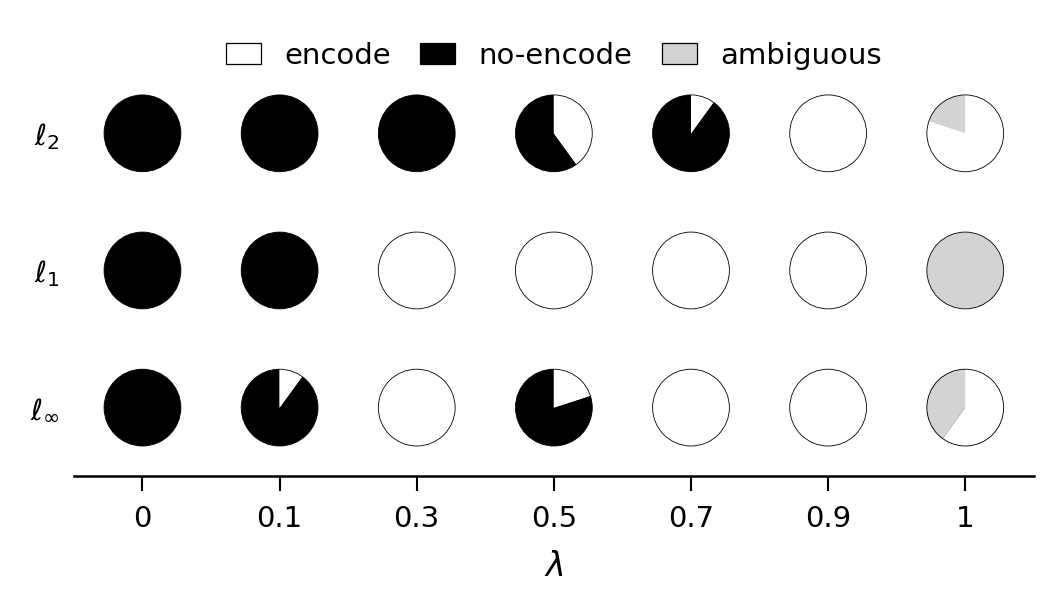

{'saved': ['mini_pie_neurips_color_styled_bw.png']}

In [18]:
# NeurIPS-style mini-pie grid (equidistant CL), with:
# - Y-axis labels: \ell_1, \ell_2, \ell_\infty
# - Legend placed above (outside); easy to move below by changing loc/bbox_to_anchor
# - All spines hidden EXCEPT the x-axis (bottom) spine
#
# Uses the same agg JSON and the new rule bands.

import json
from typing import Dict, List, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Patch

AGG_PATH = "aggregated_accuracy_by_norm_and_cl.json"
with open(AGG_PATH, "r", encoding="utf-8") as f:
    agg = json.load(f)

# ---- Styling (one-column NeurIPS) ----
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 7,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Order norms and CLs
preferred_norm_order = ["inf", "l1", "l2"]
norms = [n for n in preferred_norm_order if n in agg] + [n for n in agg if n not in preferred_norm_order]
all_cls = sorted({float(k) for n in norms for k in agg[n].keys()})

def fmt_key(x: float) -> str:
    return format(x, 'g')

# New rule bands
ID_ENCODE = (0.80, 0.865)
OOD_ENCODE = (0.09, 0.115)
NOENCODE = (0.68, 0.755)

def in_range(x: float, lo: float, hi: float) -> bool:
    return lo <= x <= hi

def classify_pair(id_acc: float, ood_acc: float) -> str:
    if in_range(id_acc, *ID_ENCODE) and in_range(ood_acc, *OOD_ENCODE):
        return "encode"
    if in_range(id_acc, *NOENCODE) and in_range(ood_acc, *NOENCODE):
        return "no-encode"
    return "ambiguous"

classes = ["no-encode", "ambiguous", "encode"]

# Fractions & majority per (norm, cl)
fractions: Dict[Tuple[str, float], List[float]] = {}
majority: Dict[Tuple[str, float], str] = {}

for norm in norms:
    clmap = agg[norm]
    for cl in all_cls:
        cell = clmap.get(fmt_key(cl))
        if not cell:
            continue
        ids = cell.get("validation/accuracy/dataloader_idx_0", [])
        oods = cell.get("validation/ood/accuracy/dataloader_idx_1", [])
        n = min(len(ids), len(oods))
        if n == 0:
            continue
        tallies = {"no-encode": 0, "ambiguous": 0, "encode": 0}
        for i in range(n):
            tallies[classify_pair(ids[i], oods[i])] += 1
        fracs = [tallies[c] / n for c in classes]
        fractions[(norm, cl)] = fracs
        majority[(norm, cl)] = max(tallies.items(), key=lambda kv: kv[1])[0]

# Positions
x_positions = {cl: i for i, cl in enumerate(all_cls)}
xtick_positions = list(x_positions.values())
xtick_labels = [fmt_key(cl) for cl in all_cls]
y_positions = {norm: i for i, norm in enumerate(norms)}
y_labels_math = {
    "inf": r"$\ell_\infty$",
    "l1":  r"$\ell_1$",
    "l2":  r"$\ell_2$",
}

# Palette (Okabe–Ito)
CLASS_COLORS = {"encode": "#009E73", "no-encode": "#E69F00", "ambiguous": "w"}
CLASS_COLORS = {
    "encode":    "#D55E00",  # vermilion
    "no-encode": "#0072B2",  # blue
    "ambiguous": "#FFFFFF"   # white
}
CLASS_COLORS = {"encode": "#1B9E77", "no-encode": "#D95F02", "ambiguous": "w"}
CLASS_COLORS = {"encode": "w", "no-encode": "k", "ambiguous": "lightgray"}
RING_STYLE = {"encode": (0.6, "solid"), "no-encode": (0.6, (0, (1, 2))), "ambiguous": (0.6, (0, (3, 2)))}

def draw_mini_pie(ax, x, y, fracs, radius, majority_label=None):
    total = sum(fracs)
    if total <= 0:
        return
    fracs = [f/total for f in fracs]
    start_angle = 90
    order = ["no-encode", "ambiguous", "encode"]
    for cls, frac in zip(order, fracs):
        if frac <= 0:
            continue
        w = Wedge((x, y), radius, start_angle, start_angle - 360*frac,
                  facecolor=CLASS_COLORS[cls], edgecolor=None, linewidth=0.1)
        ax.add_patch(w)
        start_angle -= 360*frac
    # ring with majority style
    if majority_label:
        lw, ls = RING_STYLE[majority_label]
        ls = "solid"
        lw = 0.2
    else:
        lw, ls = 0.6, "solid"
        lw = 0.0
    ring = Circle((x, y), radius, fill=False, edgecolor="k", linewidth=lw, linestyle=ls)
    ax.add_patch(ring)

# Make figure (square) and apply requested frame/legend changes
fig, ax = plt.subplots(figsize=(3.35, 3.35))
ax.set_aspect("equal", adjustable="box")

# Regular grid
ax.set_xlim(-0.5, len(all_cls) - 0.5)
ax.set_ylim(-0.5, len(norms) - 0.5)

# Labels
ax.set_xlabel(r"$\lambda$")
ax.set_yticks(list(y_positions.values()), [y_labels_math[n] for n in norms])
ax.set_xticks(xtick_positions, xtick_labels)

# Radius as fraction of a 1x1 cell
radius = 0.28

# Draw pies
for norm in norms:
    y = y_positions[norm]
    for cl in all_cls:
        key = (norm, cl)
        if key not in fractions:
            continue
        draw_mini_pie(ax, x_positions[cl], y, fractions[key], radius, majority_label=majority.get(key))

# Hide all spines except the x-axis (bottom)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
# Keep bottom visible; lighten it slightly if desired
ax.spines["bottom"].set_linewidth(0.6)

# Remove y tick marks (but keep labels)
ax.tick_params(axis="y", length=0)  # no tick lines on y

# Subtle vertical grid for CL positions (optional; comment out if undesired)
#ax.grid(True, axis="x", linestyle="--", alpha=0.25)

# Legend ABOVE; move below by changing loc/bbox_to_anchor
handles = [Patch(facecolor=CLASS_COLORS[k], edgecolor="k", label=k, lw=0.3) for k in ["encode","no-encode","ambiguous"]]
legend = ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12),
                   frameon=False, ncol=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout(pad=0.02)
out = "mini_pie_neurips_color_styled_bw.png"
plt.savefig(out, bbox_inches="tight", dpi=600)
plt.show()

{"saved": [out]}


## L_Inf runs

In [7]:
csv_file = "backbones_inf.csv"
backbones_inf = load_backbones_dict(csv_file)

{'ancient-gorge-388': {'ID': 'dty1013o',
                       'contrastive_loss_weight': 0.9,
                       'loss_norm_type': inf},
 'classic-eon-386': {'ID': 'sr7ussyu',
                     'contrastive_loss_weight': 0.7,
                     'loss_norm_type': inf},
 'earthy-cherry-390': {'ID': 'x62mmtf9',
                       'contrastive_loss_weight': 1,
                       'loss_norm_type': inf},
 'fancy-firefly-384': {'ID': '1ysalk06',
                       'contrastive_loss_weight': 0.5,
                       'loss_norm_type': inf},
 'legendary-cloud-382': {'ID': '0wqwh63j',
                         'contrastive_loss_weight': 0.3,
                         'loss_norm_type': inf}}
